# DUDE Document Understanding Dataset Benchmark Analysis

Executive Summary

**Dataset:** dude_mini - Document Understanding Dataset (DUDE)  
**Total Samples:** 404 document Q&A pairs per phase  
**Task:** Answer questions about complex, multi-page documents  
**Evaluation Metrics:** GT in Pred (PRIMARY), ANLS, Exact Match, Substring Match, Cosine Similarity

**Dataset Characteristics:**
- Complex document understanding with multi-page documents
- Requires reasoning across document layouts and structures
- Focuses on challenging real-world document scenarios
- Tests multi-page reasoning capabilities and structured document understanding

## QA Strategies

### $QA_{\text{OCR}}$: OCR parsing → LLM QA
Separate OCR extraction → LLM answers based on extracted text

### $QA_{\text{VLM-2stage}}$: VLM parsing → LLM QA  
Same VLM does both parsing and question answering

### $QA_{\text{VLM-direct}}$: Direct VLM QA
VLM sees image directly and answers question

## 1. Imports and Metadata

In [4]:
# Required imports
import sys
from pathlib import Path
from typing import List, Dict, Any, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Add parent directories to path for imports
sys.path.insert(0, str(Path("../../../..").resolve()))

# Import metrics functions
from ocr_vs_vlm.metrics.evaluation_metrics import (
    compute_anls,
    compute_exact_match,
    compute_substring_match,
    compute_ground_truth_in_prediction,
    compute_prediction_in_ground_truth,
    parse_ground_truths
)
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Set display options
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.dpi'] = 100

# Color palette for visualizations
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'mistral_ocr_3', 'donut', 
               'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        # Extract base model name (remove __ suffix for QA1/QA2 phases)
        base_model = model.split('__')[-1] if '__' in model else model
        try:
            return MODEL_ORDER.index(base_model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral OCR 2',
        'mistral_ocr_3': 'Mistral OCR 3',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    # Handle composite model names (e.g., azure_intelligence__gpt-5-mini)
    if '__' in model:
        parts = model.split('__')
        return f"{display_names.get(parts[0], parts[0])} → {display_names.get(parts[1], parts[1])}"
    return display_names.get(model, model)


def get_phase_group(phase: str) -> str:
    """Get phase group with formal notation."""
    if phase.startswith('QA1'):
        return '$QA_{\\text{OCR}}$'
    elif phase.startswith('QA2'):
        return '$QA_{\\text{VLM-2stage}}$'
    elif phase.startswith('QA3'):
        return '$QA_{\\text{VLM-direct}}$'
    elif phase.startswith('QA4'):
        return '$QA_{\\text{special}}$'
    return 'Unknown'

def get_phase_formal_name(phase: str) -> str:
    """Get formal mathematical name for a specific phase."""
    phase_mapping = {
        'QA1a': '$QA_{\\text{OCR}}^{\\text{simple}}$',
        'QA1b': '$QA_{\\text{OCR}}^{\\text{generic}}$',
        'QA1c': '$QA_{\\text{OCR}}^{\\text{task-aware}}$',
        'QA2a': '$QA_{\\text{VLM-2stage}}^{\\text{cot}}$',
        'QA2b': '$QA_{\\text{VLM-2stage}}^{\\text{generic+cot}}$',
        'QA2c': '$QA_{\\text{VLM-2stage}}^{\\text{sonnet}}$',
        'QA3a': '$QA_{\\text{VLM-direct}}^{\\text{sonnet}}$',
        'QA3b': '$QA_{\\text{VLM-direct}}^{\\text{multi}}$',
    }
    return phase_mapping.get(phase, phase)

def get_phase_strategy(phase: str) -> str:
    """Alias for get_phase_group for consistency."""
    return get_phase_group(phase)

def categorize_question_type(question: str) -> str:
    """Categorize question by type based on question words."""
    question_lower = question.lower().strip()
    
    if question_lower.startswith('what'):
        return 'What'
    elif question_lower.startswith('who'):
        return 'Who'
    elif question_lower.startswith('where'):
        return 'Where'
    elif question_lower.startswith('when'):
        return 'When'
    elif question_lower.startswith('how many') or question_lower.startswith('how much'):
        return 'How many/much'
    elif question_lower.startswith('how'):
        return 'How'
    elif question_lower.startswith('which'):
        return 'Which'
    elif question_lower.startswith('is') or question_lower.startswith('are') or question_lower.startswith('does') or question_lower.startswith('do'):
        return 'Yes/No'
    else:
        return 'Other'

## 2. Dataset Explorer

Load all phase files and explore the DUDE dataset structure.

In [5]:
# Define paths
RESULTS_DIR = Path("../../2_clean/dude_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - QA1a.csv
  - QA1b.csv
  - QA1c.csv
  - QA2a.csv
  - QA2b.csv
  - QA2c.csv
  - QA3a.csv
  - QA3b.csv


In [6]:
# Dataset configuration
DATASET_NAME = "dude_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: dude_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: QA2b, QA1c, QA1a, QA3b, QA3a, QA1b, QA2a, QA2c


In [7]:
# Load results for each phase
phase_dfs = {}

# Standard QA phases for DUDE (8 phases, no QA4)
STANDARD_PHASES = ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b']

for phase in STANDARD_PHASES:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

QA1a: 404 samples, 16 columns
QA1b: 404 samples, 16 columns
QA1c: 404 samples, 16 columns
QA2a: 404 samples, 8 columns
QA2b: 404 samples, 8 columns
QA2c: 404 samples, 14 columns
QA3a: 404 samples, 8 columns
QA3b: 404 samples, 8 columns

Total phases loaded: 8


In [8]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Question column: {'question' if 'question' in df.columns else 'NOT FOUND'}")
    print(f"  Ground truths column: {'ground_truths' if 'ground_truths' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


QA1a columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA1b columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA1c columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2a columns:
  Models: gpt-5-mini__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 8

QA2b columns:
  Models: gpt-5-mini__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 8

QA2c columns:
  Models: gpt-5-mini_gpt-5-mini, in_ground_truth_gpt-5-mini_gpt-5-mini
  Question column: question
  Ground truth

## 2.5 Data Quality Assessment ⚠️

**Critical Step:** Identify and filter out rows with empty predictions or errors to ensure accurate metrics.

In [9]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 QA1a - Total rows: 404
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)

📊 QA1b - Total rows: 404
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)

📊 QA1c - Total rows: 404
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)

📊 QA2a - Total rows: 404
  gpt-5-mini__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)

📊 QA2b - Total rows: 404
  gpt-5-mini__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)

📊 QA2c - Total rows: 404
  gpt-5-mini_gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  in_ground_truth_gpt-5-mini_

,Phase,Model,Total Rows,Valid Rows,Empty Predictions,Errors,Valid %
13,QA3a,gpt-5-mini,404,403,1,0,99.752475



⚠️  Found 1 model-phase combinations with data quality issues
These rows will be EXCLUDED from all metric calculations



## 3. Dataset Statistics

Analyze question and answer characteristics.

In [10]:
# Basic statistics for first available phase
phase_to_display = list(phase_dfs.keys())[0] if phase_dfs else None

if phase_to_display:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'question' in df_base.columns:
        # Question length statistics
        question_lengths = df_base['question'].astype(str).str.len()
        question_word_counts = df_base['question'].astype(str).str.split().str.len()
        
        print(f"\nQuestion Length (characters):")
        print(f"  Mean: {question_lengths.mean():.1f} characters")
        print(f"  Median: {question_lengths.median():.1f} characters")
        print(f"  Min: {question_lengths.min()} characters")
        print(f"  Max: {question_lengths.max()} characters")
        
        print(f"\nQuestion Length (words):")
        print(f"  Mean: {question_word_counts.mean():.1f} words")
        print(f"  Median: {question_word_counts.median():.1f} words")
        
    if 'ground_truths' in df_base.columns:
        # Answer length statistics
        df_base['parsed_gt'] = df_base['ground_truths'].apply(parse_ground_truths)
        df_base['num_ground_truths'] = df_base['parsed_gt'].apply(len)
        df_base['avg_answer_length'] = df_base['parsed_gt'].apply(
            lambda gts: np.mean([len(str(gt)) for gt in gts]) if gts else 0
        )
        
        print(f"\nGround Truth Answer Statistics:")
        print(f"  Mean answers per question: {df_base['num_ground_truths'].mean():.2f}")
        print(f"  Median answers per question: {df_base['num_ground_truths'].median():.0f}")
        print(f"  Max answers for a single question: {df_base['num_ground_truths'].max():.0f}")
        
        print(f"\nAverage Answer Length (characters):")
        print(f"  Mean: {df_base['avg_answer_length'].mean():.1f} characters")
        print(f"  Median: {df_base['avg_answer_length'].median():.1f} characters")
        print(f"  Min: {df_base['avg_answer_length'].min():.1f} characters")
        print(f"  Max: {df_base['avg_answer_length'].max():.1f} characters")


Basic statistics for phase QA1a:
Dataset Statistics:
  Total samples: 404

Question Length (characters):
  Mean: 48.3 characters
  Median: 44.0 characters
  Min: 12 characters
  Max: 164 characters

Question Length (words):
  Mean: 9.0 words
  Median: 8.0 words

Ground Truth Answer Statistics:
  Mean answers per question: 1.09
  Median answers per question: 1
  Max answers for a single question: 6

Average Answer Length (characters):
  Mean: 17.5 characters
  Median: 11.0 characters
  Min: 0.0 characters
  Max: 217.0 characters


## 4. Sample Preview

Display 10 random Q&A samples from the first available model.

### Metric Definitions:
- **GT in Pred (Ground Truth in Prediction)** [PRIMARY]: Whether the ground truth answer appears as a substring in the model's prediction. Score 1.0 if found, 0.0 otherwise.
- **ANLS (Average Normalized Levenshtein Similarity)**: Measures character-level similarity between prediction and ground truth using Levenshtein distance, normalized to 0-1 scale.
- **Cosine Similarity**: Semantic similarity between prediction and ground truth using embedding vectors. Measures meaning similarity regardless of exact wording.
- **Exact Match**: Binary score (0 or 1) indicating whether prediction exactly matches ground truth (case-insensitive).
- **Substring Match**: Binary score (0 or 1) indicating whether ground truth appears anywhere as a substring in the prediction.

### Understanding Substring Match:
**Substring Match** checks if the ground truth answer appears *anywhere* in the model's prediction as consecutive characters. It is useful for extractive QA tasks where the expected answer is a direct excerpt from the source material.

**Examples:**
- Prediction: "The answer is Paris, which is the capital of France"
  - Ground Truth: "Paris"
  - Substring Match: 1.0 ✓ (found "Paris" consecutively in prediction)

- Prediction: "The capital is in the city of Paris in France"
  - Ground Truth: "Paris"
  - Substring Match: 1.0 ✓ (still found "Paris" as consecutive characters)

- Prediction: "The capital is P-a-r-i-s with an Eiffel tower"
  - Ground Truth: "Paris"
  - Substring Match: 0.0 ✗ (letters are separated, not consecutive)

- Prediction: "The French capital starts with P and ends with S"
  - Ground Truth: "Paris"
  - Substring Match: 0.0 ✗ (individual characters present but not as substring)

## 5. Metrics Calculation

Calculate GT in Pred, ANLS, EM, Substring Match, and Cosine Similarity for all models across all samples.

In [11]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Function to calculate QA metrics for a single prediction
def calculate_qa_metrics(
    prediction: str,
    ground_truths: List[str],
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager,
    parsed_data: str = None
) -> Dict[str, float]:
    """Calculate all QA metrics for a single sample with cached embeddings."""
    if pd.isna(prediction) or prediction == "" or not ground_truths:
        return {
            'gt_in_pred': 0.0,  # PRIMARY METRIC FIRST
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'pred_in_gt': 0.0,
            'cosine_similarity': 0.0,
            'gt_in_parsed': 0.0,
        }
    
    pred_str = str(prediction)
    
    # Compute cosine similarity with first ground truth
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truths[0],
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    # Check if ground truth appears in parsed data
    gt_in_parsed = 0.0
    if parsed_data:
        parsed_str = str(parsed_data).lower()
        for gt in ground_truths:
            if gt.lower() in parsed_str:
                gt_in_parsed = 1.0
                break
    
    return {
        'gt_in_pred': compute_ground_truth_in_prediction(pred_str, ground_truths),  # PRIMARY METRIC FIRST
        'anls': compute_anls(pred_str, ground_truths, threshold=0.5),
        'exact_match': compute_exact_match(pred_str, ground_truths),
        'substring_match': compute_substring_match(pred_str, ground_truths),
        'pred_in_gt': compute_prediction_in_ground_truth(pred_str, ground_truths),
        'cosine_similarity': cosine_sim,
        'gt_in_parsed': gt_in_parsed,
    }

# Calculate metrics for all phases and models
metrics_results = {}

print("\n" + "="*120)
print("📊 CALCULATING METRICS FOR ALL PHASES AND MODELS")
print("="*120)

for phase, df in phase_dfs.items():
    print(f"\n📊 Processing phase: {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        print(f"   Processing model: {model}")
        
        # Filter to only valid rows
        valid_rows = []
        for idx, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        if not valid_rows:
            print(f"     ⚠️ No valid rows for {model}")
            continue
        
        # Calculate metrics for each valid sample
        metrics_list = []
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            ground_truths = parse_ground_truths(row['ground_truths'])
            # Get extracted_text for this model (the actual parsed data from the OCR/VLM)
            extracted_text_col = f'extracted_text_{model}'
            parsed_data = row.get(extracted_text_col, None) if extracted_text_col in row.index else None
            
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager, parsed_data
            )
            metrics_list.append(metrics)
        
        # Aggregate metrics
        if metrics_list:
            phase_metrics[model] = {
                'gt_in_pred': np.mean([m['gt_in_pred'] for m in metrics_list]),
                'anls': np.mean([m['anls'] for m in metrics_list]),
                'exact_match': np.mean([m['exact_match'] for m in metrics_list]),
                'substring_match': np.mean([m['substring_match'] for m in metrics_list]),
                'pred_in_gt': np.mean([m['pred_in_gt'] for m in metrics_list]),
                'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
                'gt_in_parsed': np.mean([m['gt_in_parsed'] for m in metrics_list]),
                'valid_samples': len(valid_rows),
                'total_samples': len(df)
            }
            
            print(f"     ✅ Calculated metrics for {len(valid_rows)} valid samples")
    
    metrics_results[phase] = phase_metrics

print(f"\n✅ Metrics calculation complete!")
print(f"   Phases: {len(metrics_results)}")
print(f"   Total models processed: {sum(len(m) for m in metrics_results.values())}")
print("\n" + "="*120)




📊 CALCULATING METRICS FOR ALL PHASES AND MODELS

📊 Processing phase: QA1a...
   Processing model: azure_intelligence__gpt-5-mini


   azure_intelligence__gpt-5-mini:   0%|          | 0/404 [00:00<?, ?it/s]

Identical embeddings for sample 06cc755612621483103dd1752c3927f7_20bc915e220e460a539fb622f1085943, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 098bda18540fa5e097196c3f7898d4f1_c55543406c7e546faafb9246d0fff991, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_a19fd127268fb9493257f12d53d5d53d, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_c765b29277f8fc85f08f4560a244f5ea, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0e22690bb0a737fae78b1f8c6fc0dede_627dff624e1cf732f3cc27a7edfc3ddc, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_d0fc0282ab9a26f31092bb8bcc1a0e35, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 219acc43859e61b1a16d9e52a42e7216_136cbfbd28f461b0057dd17b76d99409, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 28a3508ea6ad3b25

     ✅ Calculated metrics for 404 valid samples
   Processing model: mistral_document_ai__gpt-5-mini


   mistral_document_ai__gpt-5-mini:   0%|          | 0/404 [00:00<?, ?it/s]

...

Identical embeddings for sample 06cc755612621483103dd1752c3927f7_6489017023d8d62731ca8126007cd05b, model gpt-5-mini
Identical embeddings for sample 09a039762a17ef85fbe52be984e62740_c8ffa164c8f890a16b521db4c37453fa, model gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_a19fd127268fb9493257f12d53d5d53d, model gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_c765b29277f8fc85f08f4560a244f5ea, model gpt-5-mini
Identical embeddings for sample 0ce23d1b787bf894de339a4dae34f5f4_13fa01a95a4c198477e1a89d186a67a4, model gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_0080660a09ef69357e81ad256a3df234, model gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_d0fc0282ab9a26f31092bb8bcc1a0e35, model gpt-5-mini
Identical embeddings for sample 219acc43859e61b1a16d9e52a42e7216_136cbfbd28f461b0057dd17b76d99409, model gpt-5-mini
Identical embeddings for sample 2369d6d8c2d8a3bc6efb871d1325c411_3db1ebd

     ✅ Calculated metrics for 403 valid samples

📊 Processing phase: QA3b...
   Processing model: gpt-5-mini


   gpt-5-mini:   0%|          | 0/404 [00:00<?, ?it/s]

Identical embeddings for sample 001d6f557c342ef5a67cd38a29da9e83_6d7cc36223d7bf354edc3eeff4ad0577, model gpt-5-mini
Identical embeddings for sample 06cc755612621483103dd1752c3927f7_ae4b30f6e44a34292d572b1931c4b8ac, model gpt-5-mini
Identical embeddings for sample 0ce23d1b787bf894de339a4dae34f5f4_13fa01a95a4c198477e1a89d186a67a4, model gpt-5-mini
Identical embeddings for sample 0e22690bb0a737fae78b1f8c6fc0dede_627dff624e1cf732f3cc27a7edfc3ddc, model gpt-5-mini
Identical embeddings for sample 11ef3f295ed60f2d864f3028754e11c3_ca3d1b507a59189ffe4cd45c4e01fa85, model gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_d0fc0282ab9a26f31092bb8bcc1a0e35, model gpt-5-mini
Identical embeddings for sample 219acc43859e61b1a16d9e52a42e7216_136cbfbd28f461b0057dd17b76d99409, model gpt-5-mini
Identical embeddings for sample 2369d6d8c2d8a3bc6efb871d1325c411_3db1ebd7635421d9c8cf7a947eccab03, model gpt-5-mini
Identical embeddings for sample 2f430bfa8fcbc42ca17a31234fda3842_1e6c0ee

     ✅ Calculated metrics for 404 valid samples

✅ Metrics calculation complete!
   Phases: 8
   Total models processed: 15



## 6. Metrics Summary Table

Aggregate view of all metrics across phases and models.

In [12]:
# Create a summary DataFrame
summary_data = []

for strategy, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': strategy,
            'Model': model,
            'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC FIRST
            'ANLS': metrics['anls'],
            'Exact Match': metrics['exact_match'],
            'Substring Match': metrics['substring_match'],
            'Pred in GT': metrics['pred_in_gt'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'GT in Parsed Data': metrics.get('gt_in_parsed', 0.0),
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)
summary_df['Strategy'] = summary_df['Phase'].apply(get_phase_strategy)


print("\n🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)")
print("=" * 150)
print("\nMetrics Summary (sorted by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
display(summary_df.sort_values(['Phase', 'GT in Pred'], ascending=[True, False]))

# Best model per strategy (by GT in Pred - PRIMARY METRIC)
print("\n" + "=" * 150)
print("🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    best_model = strategy_data.loc[strategy_data['GT in Pred'].idxmax()]
    print(f"  {strategy}: {get_model_display_name(best_model['Model'])}")
    print(f"    🎯 GT in Pred: {best_model['GT in Pred']:.4f} [PRIMARY]")
    print(f"       ANLS: {best_model['ANLS']:.4f}, EM: {best_model['Exact Match']:.4f}")
    print(f"       Valid samples: {best_model['Valid Samples']}/{best_model['Total Samples']}")

print("\n" + "=" * 150)



🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)

Metrics Summary (sorted by GT in Pred - PRIMARY METRIC):


,Phase,Model,GT in Pred,ANLS,Exact Match,Substring Match,Pred in GT,Cosine Similarity,GT in Parsed Data,Valid Samples,Total Samples,Strategy
0,QA1a,azure_intelligence__gpt-5-mini,0.519802,0.355502,0.205446,0.547030,0.232673,0.596942,0.504950,404,404,$QA_{\text{OCR}}$
2,QA1a,mistral_ocr_3__gpt-5-mini,0.512376,0.341063,0.195545,0.529703,0.212871,0.590969,0.391089,404,404,$QA_{\text{OCR}}$
1,QA1a,mistral_document_ai__gpt-5-mini,0.504950,0.344145,0.195545,0.529703,0.220297,0.592875,0.467822,404,404,$QA_{\text{OCR}}$
3,QA1b,azure_intelligence__gpt-5-mini,0.475248,0.503817,0.356436,0.519802,0.400990,0.630886,0.504950,404,404,$QA_{\text{OCR}}$
4,QA1b,mistral_document_ai__gpt-5-mini,0.475248,0.513302,0.363861,0.524752,0.413366,0.634763,0.470297,404,404,$QA_{\text{OCR}}$
5,QA1b,mistral_ocr_3__gpt-5-mini,0.467822,0.504257,0.351485,0.512376,0.396040,0.634677,0.386139,404,404,$QA_{\text{OCR}}$
8,QA1c,mistral_ocr_3__gpt-5-mini,0.579208,0.000000,0.000000,0.579208,0.000000,0.385737,0.391089,404,404,$QA_{\text{OCR}}$
6,QA1c,azure_intelligence__gpt-5-mini,0.566832,0.000000,0.000000,0.566832,0.000000,0.381981,0.504950,404,404,$QA_{\text{OCR}}$
7,QA1c,mistral_document_ai__gpt-5-mini,0.566832,0.003540,0.000000,0.566832,0.000000,0.386257,0.457921,404,404,$QA_{\text{OCR}}$
9,QA2a,gpt-5-mini__gpt-5-mini,0.490099,0.345051,0.180693,0.517327,0.207921,0.583039,0.465347,404,404,$QA_{\text{VLM-2stage}}$



🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):
  $QA_{\text{OCR}}$: Mistral OCR 3 → GPT-5 Mini
    🎯 GT in Pred: 0.5792 [PRIMARY]
       ANLS: 0.0000, EM: 0.0000
       Valid samples: 404/404
  $QA_{\text{VLM-2stage}}$: gpt-5-mini_gpt-5-mini
    🎯 GT in Pred: 0.5594 [PRIMARY]
       ANLS: 0.0000, EM: 0.0000
       Valid samples: 404/404
  $QA_{\text{VLM-direct}}$: GPT-5 Mini
    🎯 GT in Pred: 0.5000 [PRIMARY]
       ANLS: 0.3906, EM: 0.2302
       Valid samples: 404/404



In [13]:
# Display 10 random samples with metrics
if len(phase_dfs) > 0:
    # Use first available phase
    display_phase = list(phase_dfs.keys())[0]
    df_display = phase_dfs[display_phase].copy()
    
    # Get first model for sample display
    pred_cols = [col for col in df_display.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    pred_col = pred_cols[0]
    err_col = f'error_{first_model}'
    
    # Filter to valid rows only
    valid_rows = []
    for idx, row in df_display.iterrows():
        if is_valid_row(row, pred_col, err_col):
            valid_rows.append((idx, row))
    
    if len(valid_rows) > 0:
        # Randomly select 10 samples
        import random
        sample_indices = random.sample(range(len(valid_rows)), min(10, len(valid_rows)))
        
        print(f"\n📋 Random Sample Preview ({get_model_display_name(first_model)}) - Phase {display_phase}")
        print("=" * 100)
        
        for sample_num, idx_in_valid in enumerate(sample_indices, 1):
            _, row = valid_rows[idx_in_valid]
            
            # Get ground truths
            ground_truths = parse_ground_truths(row['ground_truths'])
            gt_text = ground_truths[0] if ground_truths else "N/A"
            
            # Calculate metrics using the full metrics function
            prediction = str(row[pred_col])
            metrics = calculate_qa_metrics(
                prediction=prediction,
                ground_truths=ground_truths,
                phase=display_phase,
                sample_id=row['sample_id'],
                model=first_model,
                emb_manager=embedding_manager
            )
            
            # Print sample in requested format
            print(f"\nSample {sample_num}: GT_in_pred: {metrics['gt_in_pred']:.4f}, ANLS: {metrics['anls']:.4f}")
            print(f"Cosine Similarity: {metrics['cosine_similarity']:.4f}")
            print(f"Exact Match: {metrics['exact_match']:.4f}")
            print(f"Substring Match: {metrics['substring_match']:.4f}")
            print(f"Prediction: {prediction}")
            print(f"Ground truth: {gt_text}")
        
        print("\n" + "=" * 100)


📋 Random Sample Preview (Azure Intelligence → GPT-5 Mini) - Phase QA1a

Sample 1: GT_in_pred: 0.0000, ANLS: 0.9375
Cosine Similarity: 0.6804
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: Fenchurch Street
Ground truth: Fenchuch Street

Sample 2: GT_in_pred: 0.0000, ANLS: 0.0000
Cosine Similarity: 0.5286
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: 0
Ground truth: 3

Sample 3: GT_in_pred: 0.0000, ANLS: 0.0000
Cosine Similarity: 0.3530
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: The certificate refers to "communicable diseases listed in Section 103 of the Sanitary Code (see over)". Examples of those contagious diseases typically listed are: smallpox, cholera, plague, yellow fever, diphtheria, scarlet fever and typhoid fever. See the back of the certificate or Section 103 of the Sanitary Code for the complete, authoritative list.
Ground truth: Asiatic Cholera

Sample 4: GT_in_pred: 0.0000, ANLS: 0.0000
Cosine Similarity: 0.4745
Exact Match: 0.0000
Substrin

In [14]:
# Display 10 random samples with metrics
if len(phase_dfs) > 0:
    # Use first available phase
    display_phase = list(phase_dfs.keys())[0]
    df_display = phase_dfs[display_phase].copy()
    
    # Get first model for sample display
    pred_cols = [col for col in df_display.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    pred_col = pred_cols[0]
    err_col = f'error_{first_model}'
    
    # Filter to valid rows only
    valid_rows = []
    for idx, row in df_display.iterrows():
        if is_valid_row(row, pred_col, err_col):
            valid_rows.append((idx, row))
    
    if len(valid_rows) > 0:
        # Randomly select 10 samples
        import random
        sample_indices = random.sample(range(len(valid_rows)), min(10, len(valid_rows)))
        
        print(f"\n📋 Random Sample Preview ({get_model_display_name(first_model)}) - Phase {display_phase}")
        print("=" * 100)
        
        for sample_num, idx_in_valid in enumerate(sample_indices, 1):
            _, row = valid_rows[idx_in_valid]
            
            # Get ground truths
            ground_truths = parse_ground_truths(row['ground_truths'])
            gt_text = ground_truths[0] if ground_truths else "N/A"
            
            # Calculate metrics
            prediction = str(row[pred_col])
            metrics = calculate_qa_metrics(
                prediction=prediction,
                ground_truths=ground_truths,
                phase=display_phase,
                sample_id=row['sample_id'],
                model=first_model,
                emb_manager=embedding_manager
            )
            
            # Print sample in requested format
            print(f"Sample {sample_num}: GT_in_pred: {metrics['gt_in_pred']:.4f}, ANLS: {metrics['anls']:.4f}")
            print(f"Cosine Similarity: {metrics['cosine_similarity']:.4f}")
            print(f"Exact Match: {metrics['exact_match']:.4f}")
            print(f"Substring Match: {metrics['substring_match']:.4f}")
            print(f"Prediction: {prediction}")
            print(f"Ground truth: {gt_text}")
            print()
        
        print("=" * 100)

Identical embeddings for sample e03d8d6489565afd65e6b325ea02016b_990ef33169489f10794355ebeb3aab24, model azure_intelligence__gpt-5-mini



📋 Random Sample Preview (Azure Intelligence → GPT-5 Mini) - Phase QA1a
Sample 1: GT_in_pred: 1.0000, ANLS: 0.0000
Cosine Similarity: 0.2761
Exact Match: 0.0000
Substring Match: 1.0000
Prediction: Yes — there is a handwritten signature near the bottom right above the company name.
Ground truth: Yes

Sample 2: GT_in_pred: 0.0000, ANLS: 0.0000
Cosine Similarity: 0.7142
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: A certified death certificate (a vital record / Certificate of Death).
Ground truth: Certificate od Death

Sample 3: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 1.0000
Exact Match: 1.0000
Substring Match: 1.0000
Prediction: Jimenez Central School
Ground truth: Jimenez Central School

Sample 4: GT_in_pred: 1.0000, ANLS: 0.0000
Cosine Similarity: 0.2221
Exact Match: 0.0000
Substring Match: 1.0000
Prediction: Yes. The document includes a large spreadsheet-style table (image of a table) as a graphic; there are no photos or other charts.
Ground truth: No

Sample 5:

## 7. Visualizations - Bar Charts

Compare all metrics across models and phases.

In [15]:
# Bar charts for each metric (PRIMARY METRIC FIRST), organized by strategy
strategies = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']

for strategy in strategies:
    # Filter summary_df for this strategy
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    if strategy_data.empty:
        continue
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Pivot data for this metric
        pivot_data = strategy_data.pivot_table(
            index='Model', 
            columns='Phase', 
            values=metric, 
            aggfunc='mean'
        )
        
        # Sort models
        pivot_data = pivot_data.reindex(sort_models(pivot_data.index.tolist()))
        
        pivot_data.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_data.columns)], 
                       alpha=0.85, width=0.8)
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        title_suffix = " [PRIMARY METRIC]" if metric == 'GT in Pred' else ""
        
        ax.set_title(f'{title_prefix}{metric} by Model{title_suffix}',
                     fontsize=15 if metric == 'GT in Pred' else 14,
                     fontweight='bold', pad=15)
        ax.set_xlabel('Model', fontsize=13)
        ax.set_ylabel(metric, fontsize=13)
        ax.legend(title='Phase', title_fontsize=12, fontsize=10, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xticklabels([get_model_display_name(m) for m in pivot_data.index], 
                           rotation=45, ha='right')
        ax.set_ylim(0, 1.05)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
    
    # Hide last subplot if not needed
    if len(metrics_to_plot) < 6:
        axes[-1].set_visible(False)
    
    fig.suptitle(f'{strategy} - Metrics by Model and Phase', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")


🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric


## 8. Visualizations - Box Plots

Distribution analysis showing variance and outliers.

In [16]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

print("Calculating per-sample metrics for box plots (using only valid rows)...")
for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in tqdm(pred_cols, desc=f"Strategy {phase}", leave=False):
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        for _, row in df.iterrows():
            if not is_valid_row(row, pred_col, err_col):
                continue  # Skip invalid rows
            
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager
            )
            
            sample_metrics_data.append({
                'Strategy': phase,
                'Model': model,
                'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC
                'ANLS': metrics['anls'],
                'Exact Match': metrics['exact_match'],
                'Substring Match': metrics['substring_match'],
                'Cosine Similarity': metrics['cosine_similarity']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Separate figures for QA1, QA2, and QA3
strategies = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
metrics_for_boxplot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']

for strategy in strategies:
    strategy_data = sample_metrics_df[sample_metrics_df['Strategy'].apply(get_phase_strategy) == strategy]
    if strategy_data.empty:
        continue
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics_for_boxplot):
        ax = axes[idx]
        
        # Create box plot
        strategy_data_sorted = strategy_data.copy()
        strategy_data_sorted['Model'] = pd.Categorical(
            strategy_data_sorted['Model'],
            categories=sort_models(strategy_data_sorted['Model'].unique().tolist()),
            ordered=True
        )
        
        sns.boxplot(data=strategy_data_sorted, x='Model', y=metric, ax=ax)
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric} Distribution - {strategy}', 
                    fontsize=15 if metric == 'GT in Pred' else 14, 
                    fontweight='bold', pad=15)
        ax.set_xlabel('Model', fontsize=13)
        ax.set_ylabel(metric, fontsize=13)
        ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Hide last subplot if not needed
    if len(metrics_for_boxplot) < 6:
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: Distributions show only valid samples (empty/error rows excluded)")

Calculating per-sample metrics for box plots (using only valid rows)...


Strategy QA1a:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample 06cc755612621483103dd1752c3927f7_20bc915e220e460a539fb622f1085943, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 098bda18540fa5e097196c3f7898d4f1_c55543406c7e546faafb9246d0fff991, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_a19fd127268fb9493257f12d53d5d53d, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_c765b29277f8fc85f08f4560a244f5ea, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0e22690bb0a737fae78b1f8c6fc0dede_627dff624e1cf732f3cc27a7edfc3ddc, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_d0fc0282ab9a26f31092bb8bcc1a0e35, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 219acc43859e61b1a16d9e52a42e7216_136cbfbd28f461b0057dd17b76d99409, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 28a3508ea6ad3b25

Strategy QA1b:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample 001d6f557c342ef5a67cd38a29da9e83_6d7cc36223d7bf354edc3eeff4ad0577, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 03b0ce944fb20ef2d3bd350d172344f4_e229289181e94b5c9e04f541ceb3c20a, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 06cc755612621483103dd1752c3927f7_6489017023d8d62731ca8126007cd05b, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 06cc755612621483103dd1752c3927f7_ae4b30f6e44a34292d572b1931c4b8ac, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 098bda18540fa5e097196c3f7898d4f1_9f4da5b4e842a55980e06bab593c39e1, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_38e51a2f72a54368fa57c921916f7cba, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_a19fd127268fb9493257f12d53d5d53d, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d333

...

Strategy QA3a:   0%|          | 0/1 [00:00<?, ?it/s]

Identical embeddings for sample 06cc755612621483103dd1752c3927f7_6489017023d8d62731ca8126007cd05b, model gpt-5-mini
Identical embeddings for sample 09a039762a17ef85fbe52be984e62740_c8ffa164c8f890a16b521db4c37453fa, model gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_a19fd127268fb9493257f12d53d5d53d, model gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_c765b29277f8fc85f08f4560a244f5ea, model gpt-5-mini
Identical embeddings for sample 0ce23d1b787bf894de339a4dae34f5f4_13fa01a95a4c198477e1a89d186a67a4, model gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_0080660a09ef69357e81ad256a3df234, model gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_d0fc0282ab9a26f31092bb8bcc1a0e35, model gpt-5-mini
Identical embeddings for sample 219acc43859e61b1a16d9e52a42e7216_136cbfbd28f461b0057dd17b76d99409, model gpt-5-mini
Identical embeddings for sample 2369d6d8c2d8a3bc6efb871d1325c411_3db1ebd

Strategy QA3b:   0%|          | 0/1 [00:00<?, ?it/s]

Identical embeddings for sample 001d6f557c342ef5a67cd38a29da9e83_6d7cc36223d7bf354edc3eeff4ad0577, model gpt-5-mini
Identical embeddings for sample 06cc755612621483103dd1752c3927f7_ae4b30f6e44a34292d572b1931c4b8ac, model gpt-5-mini
Identical embeddings for sample 0ce23d1b787bf894de339a4dae34f5f4_13fa01a95a4c198477e1a89d186a67a4, model gpt-5-mini
Identical embeddings for sample 0e22690bb0a737fae78b1f8c6fc0dede_627dff624e1cf732f3cc27a7edfc3ddc, model gpt-5-mini
Identical embeddings for sample 11ef3f295ed60f2d864f3028754e11c3_ca3d1b507a59189ffe4cd45c4e01fa85, model gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_d0fc0282ab9a26f31092bb8bcc1a0e35, model gpt-5-mini
Identical embeddings for sample 219acc43859e61b1a16d9e52a42e7216_136cbfbd28f461b0057dd17b76d99409, model gpt-5-mini
Identical embeddings for sample 2369d6d8c2d8a3bc6efb871d1325c411_3db1ebd7635421d9c8cf7a947eccab03, model gpt-5-mini
Identical embeddings for sample 2f430bfa8fcbc42ca17a31234fda3842_1e6c0ee


🎯 Note: Distributions show only valid samples (empty/error rows excluded)


## 9. Visualizations - Heatmaps

Model × Phase performance heatmaps.


Heatmaps for QA1 (OCR+VLM)

GT in Pred Table for QA1 (OCR+VLM):


,QA1a,QA1b,QA1c
Azure Intelligence → GPT-5 Mini,0.519802,0.475248,0.566832
Mistral OCR 3 → GPT-5 Mini,0.512376,0.467822,0.579208
Mistral OCR 2 → GPT-5 Mini,0.504950,0.475248,0.566832



ANLS Table for QA1 (OCR+VLM):


,QA1a,QA1b,QA1c
Azure Intelligence → GPT-5 Mini,0.355502,0.503817,0.00000
Mistral OCR 3 → GPT-5 Mini,0.341063,0.504257,0.00000
Mistral OCR 2 → GPT-5 Mini,0.344145,0.513302,0.00354


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


...

,QA1a,QA1b,QA1c
Azure Intelligence → GPT-5 Mini,0.205446,0.356436,0.0
Mistral OCR 3 → GPT-5 Mini,0.195545,0.351485,0.0
Mistral OCR 2 → GPT-5 Mini,0.195545,0.363861,0.0


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()



Cosine Similarity Table for QA1 (OCR+VLM):


,QA1a,QA1b,QA1c
Azure Intelligence → GPT-5 Mini,0.596942,0.630886,0.381981
Mistral OCR 3 → GPT-5 Mini,0.590969,0.634677,0.385737
Mistral OCR 2 → GPT-5 Mini,0.592875,0.634763,0.386257


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


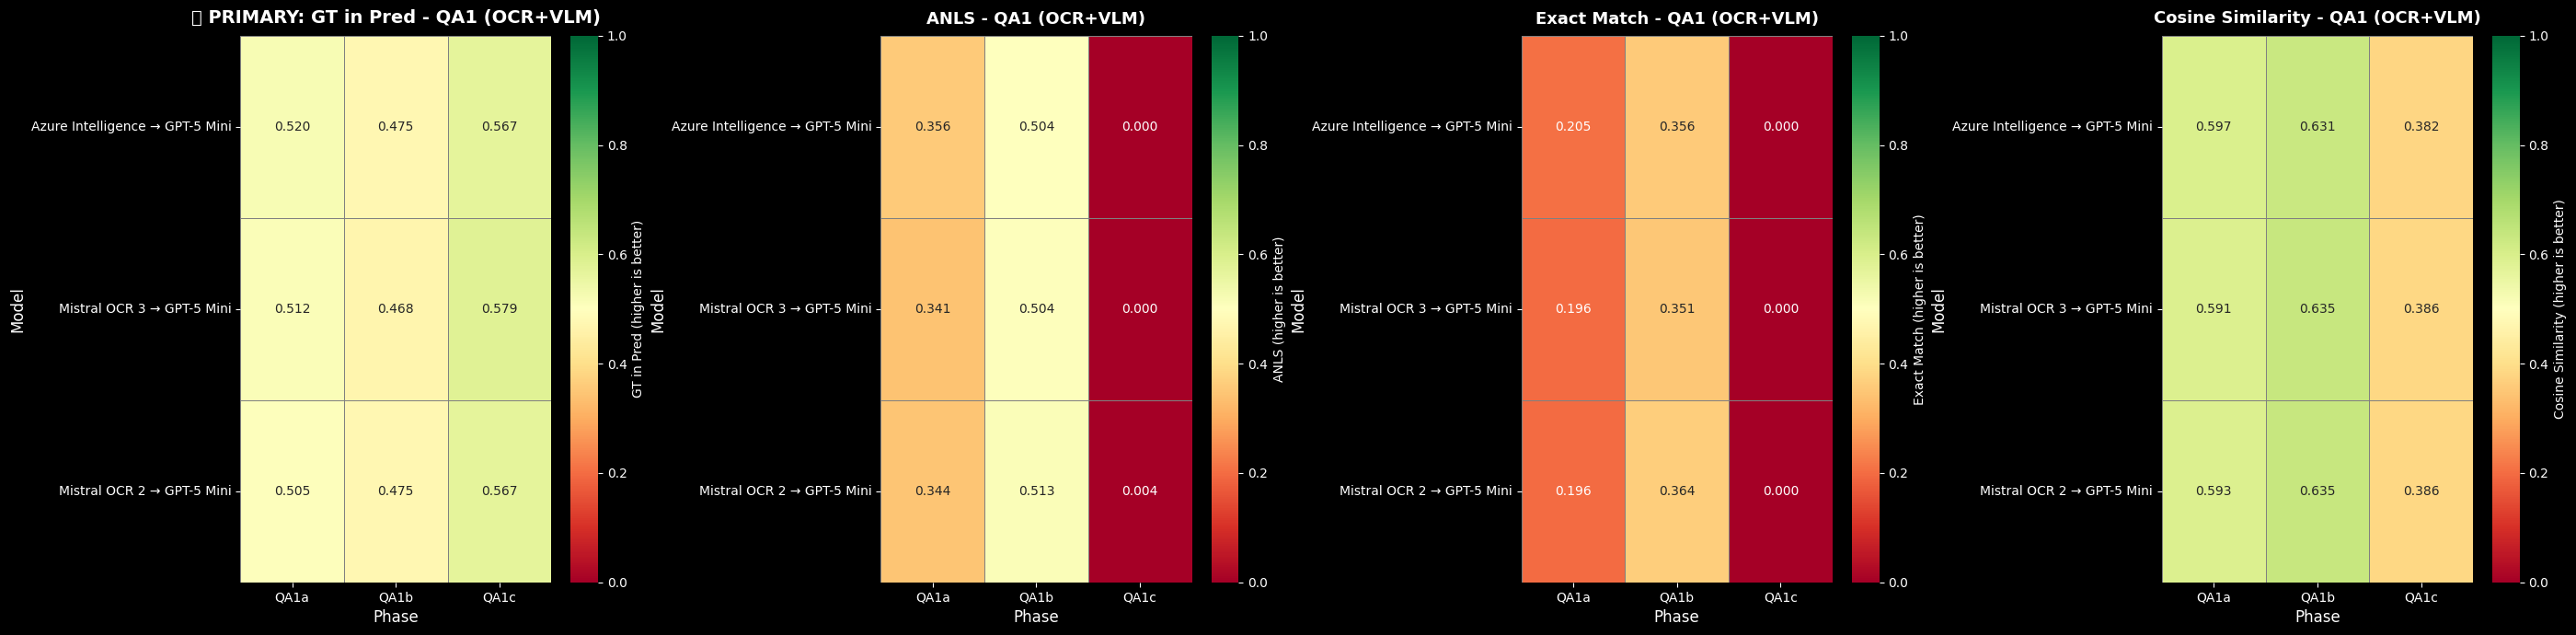


Heatmaps for QA2 (VLM Parse+QA)

GT in Pred Table for QA2 (VLM Parse+QA):


,QA2a,QA2b,QA2c
GPT-5 Mini → GPT-5 Mini,0.490099,0.44802,NaN
in_ground_truth_gpt-5-mini_gpt-5-mini,NaN,NaN,0.000000
gpt-5-mini_gpt-5-mini,NaN,NaN,0.559406



ANLS Table for QA2 (VLM Parse+QA):


,QA2a,QA2b,QA2c
GPT-5 Mini → GPT-5 Mini,0.345051,0.506398,NaN
in_ground_truth_gpt-5-mini_gpt-5-mini,NaN,NaN,0.002888
gpt-5-mini_gpt-5-mini,NaN,NaN,0.000000


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


...

,QA2a,QA2b,QA2c
GPT-5 Mini → GPT-5 Mini,0.180693,0.336634,NaN
in_ground_truth_gpt-5-mini_gpt-5-mini,NaN,NaN,0.0
gpt-5-mini_gpt-5-mini,NaN,NaN,0.0



Cosine Similarity Table for QA2 (VLM Parse+QA):


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


,QA2a,QA2b,QA2c
GPT-5 Mini → GPT-5 Mini,0.583039,0.631218,NaN
in_ground_truth_gpt-5-mini_gpt-5-mini,NaN,NaN,0.209963
gpt-5-mini_gpt-5-mini,NaN,NaN,0.380457


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


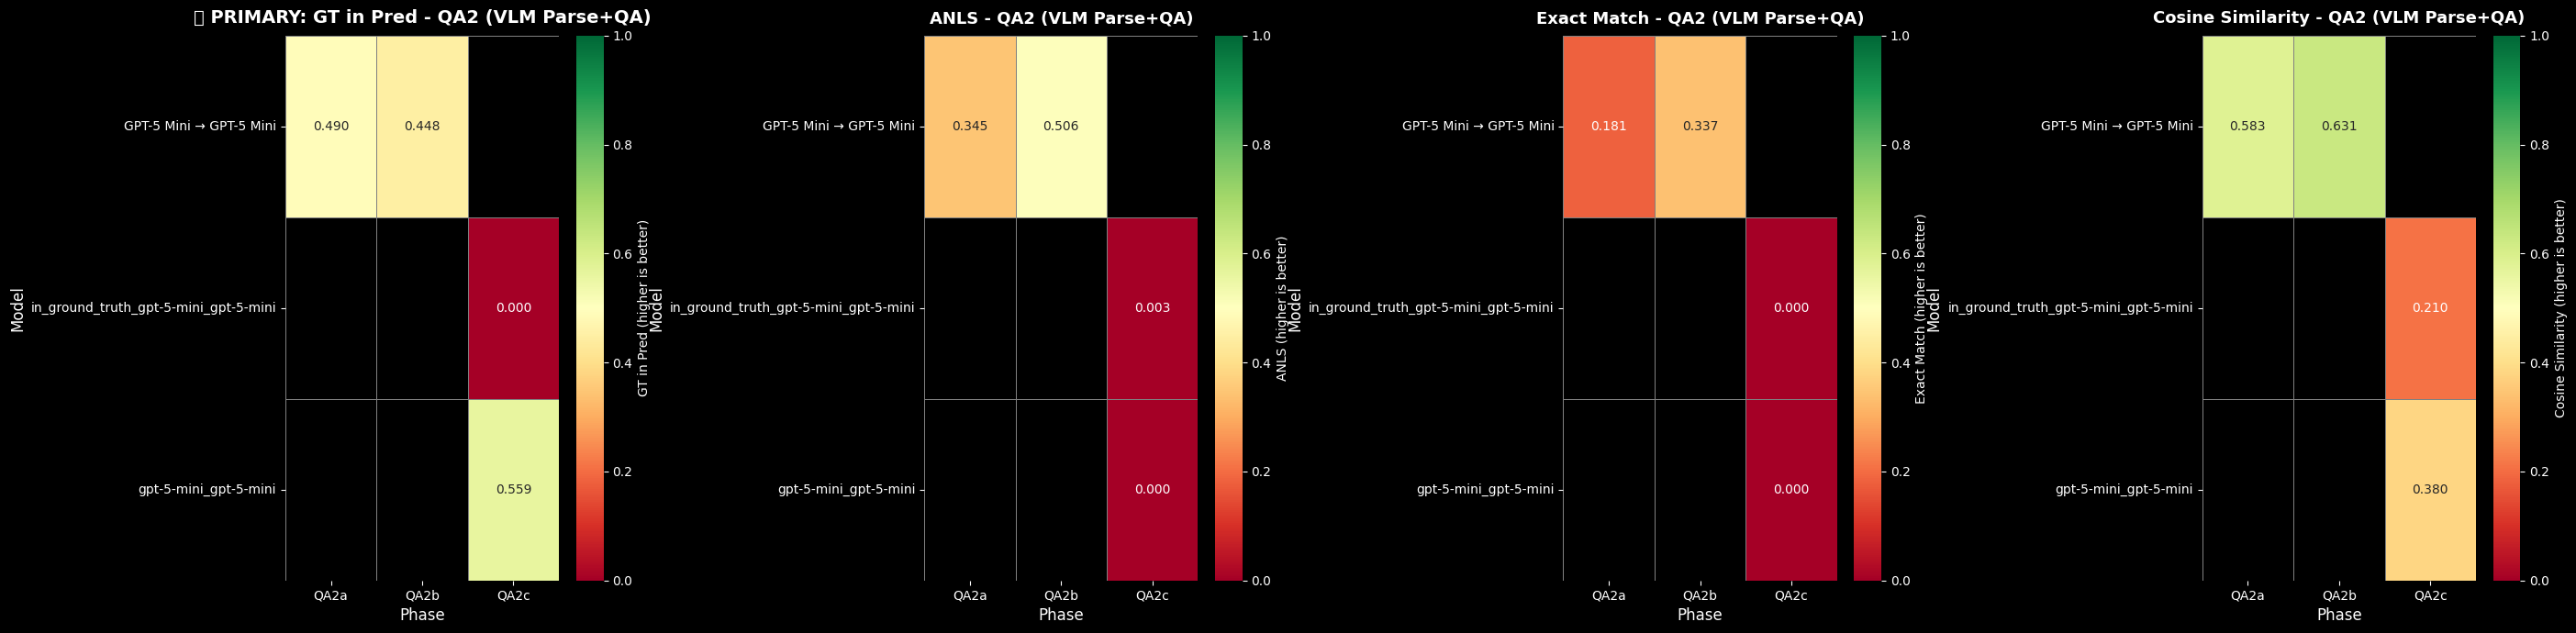


Heatmaps for QA3 (Direct VQA)

GT in Pred Table for QA3 (Direct VQA):


,QA3a,QA3b
GPT-5 Mini,0.493797,0.5



ANLS Table for QA3 (Direct VQA):


,QA3a,QA3b
GPT-5 Mini,0.363116,0.390613



Exact Match Table for QA3 (Direct VQA):


...

,QA3a,QA3b
GPT-5 Mini,0.208437,0.230198



Cosine Similarity Table for QA3 (Direct VQA):


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


,QA3a,QA3b
GPT-5 Mini,0.604007,0.589551


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


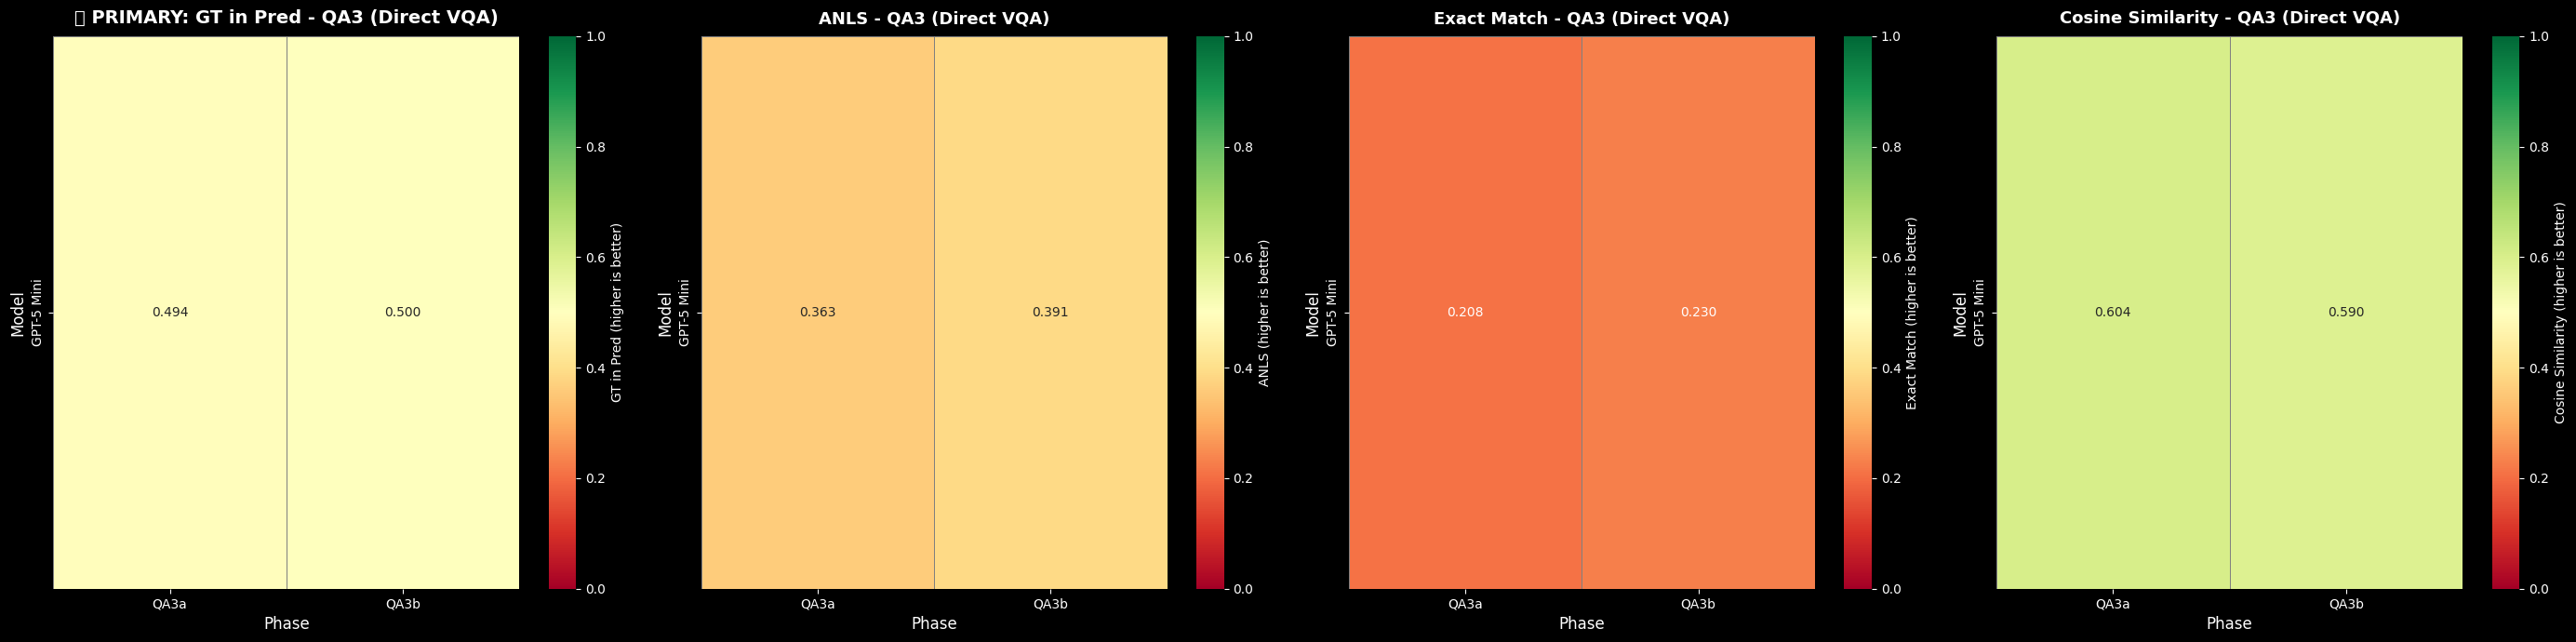


🎯 Note: 'GT in Pred' heatmaps show PRIMARY metric performance


In [17]:
# Create heatmaps for key metrics (PRIMARY METRIC FIRST), separated by strategy
# print these as tables as well
metrics_to_show = ['GT in Pred', 'ANLS', 'Exact Match', 'Cosine Similarity']

# Define strategies and their phases
strategy_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

for strategy_name, phases in strategy_groups.items():
    print(f"\n{'='*80}")
    print(f"Heatmaps for {strategy_name}")
    print(f"{'='*80}")
    
    # Filter phases for this strategy - check which ones are in metrics_results
    strategy_phase_names = [p for p in phases if p in metrics_results]
    if not strategy_phase_names:
        print(f"⚠️ No phases found for {strategy_name}")
        continue
    
    fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(7 * len(metrics_to_show), 7))
    
    if len(metrics_to_show) == 1:
        axes = [axes]
    
    for idx, metric_name in enumerate(metrics_to_show):
        ax = axes[idx]
        
        # Create heatmap data: rows = models, columns = phases in this strategy
        heatmap_data = []
        model_names = []
        
        # Get all unique models across the phases in this strategy
        all_models = set()
        for phase in strategy_phase_names:
            if phase in metrics_results:
                all_models.update(metrics_results[phase].keys())
        all_models = sort_models(list(all_models))
        
        # Build heatmap data
        for model in all_models:
            row_data = []
            for phase in strategy_phase_names:
                if phase in metrics_results and model in metrics_results[phase]:
                    # Map metric name to key
                    metric_key = metric_name.lower().replace(' ', '_')
                    value = metrics_results[phase][model].get(metric_key, np.nan)
                    row_data.append(value)
                else:
                    row_data.append(np.nan)
            
            heatmap_data.append(row_data)
            model_names.append(model)
        
        heatmap_df = pd.DataFrame(
            heatmap_data,
            index=[get_model_display_name(m) for m in model_names],
            columns=strategy_phase_names
        )
        
        # Print the table
        print(f"\n{metric_name} Table for {strategy_name}:")
        display(heatmap_df)
        
        # Use colormap: green for good, red for bad (all QA metrics: higher is better)
        cmap = 'RdYlGn'
        cbar_label = f'{metric_name} (higher is better)'
        
        sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                    ax=ax, cbar_kws={'label': cbar_label}, 
                    vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
        
        # Emphasize primary metric in title
        title_prefix = "🎯 PRIMARY: " if metric_name == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric_name} - {strategy_name}', 
                    fontsize=14 if metric_name == 'GT in Pred' else 13, 
                    fontweight='bold', pad=10)
        ax.set_xlabel('Phase', fontsize=12)
        ax.set_ylabel('Model', fontsize=12)
    
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' heatmaps show PRIMARY metric performance")

## 10. Visualizations - Scatter Plots

Correlation analysis between metrics.

/var/folders/g9/llcmfs150lg102rht49jlz980000gq/T/ipykernel_44647/3644527069.py:40: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


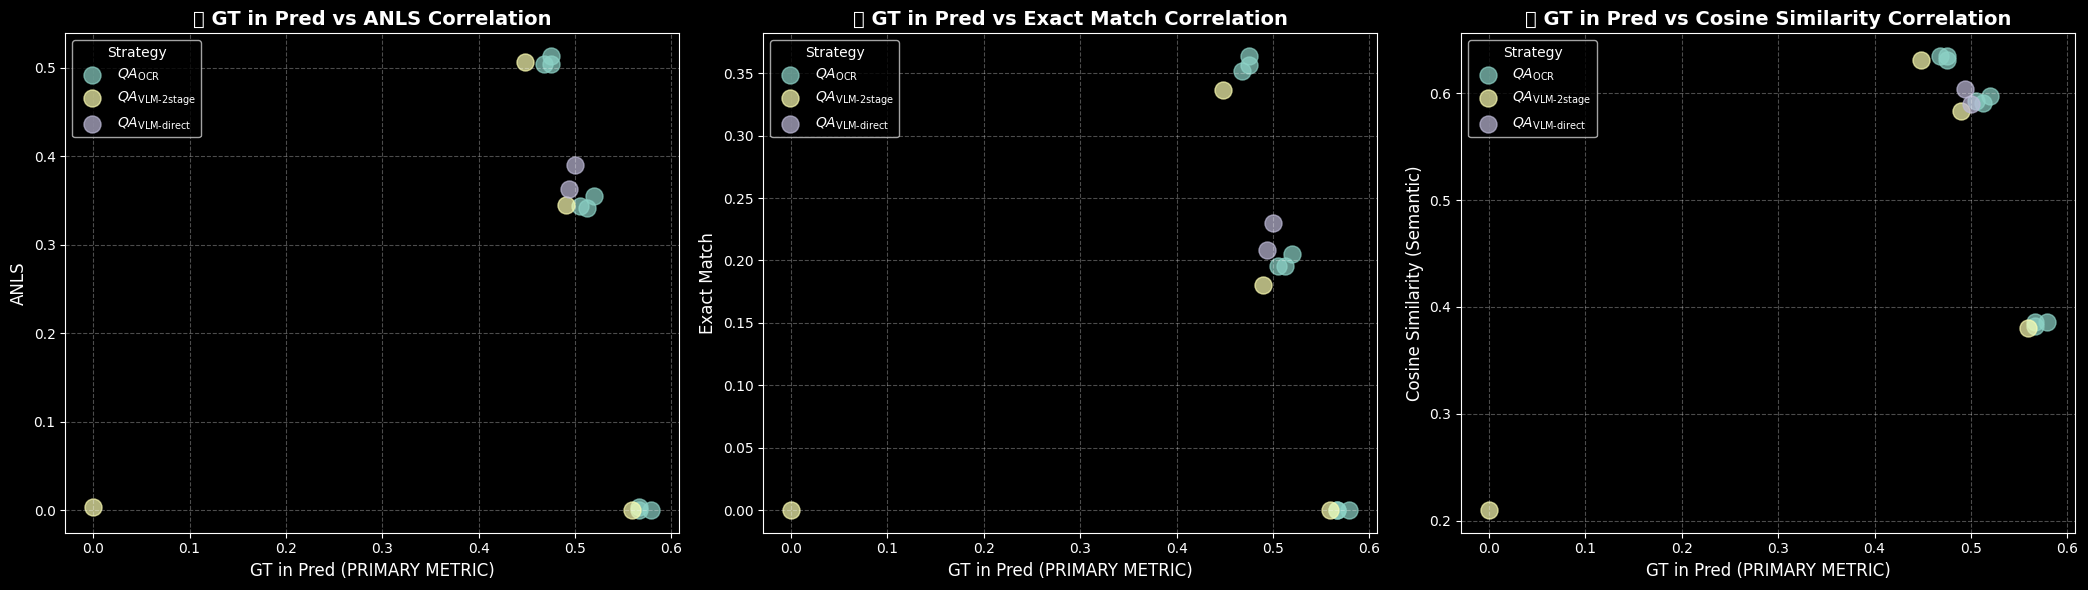


🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)


In [18]:
# Scatter plots: GT in Pred (PRIMARY) vs other metrics
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# GT in Pred vs ANLS
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['GT in Pred'], strategy_data['ANLS'],
                s=150, alpha=0.7, label=strategy)
ax1.set_title('🎯 GT in Pred vs ANLS Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax1.set_ylabel('ANLS', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Exact Match
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['GT in Pred'], strategy_data['Exact Match'],
                s=150, alpha=0.7, label=strategy)
ax2.set_title('🎯 GT in Pred vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax2.set_ylabel('Exact Match', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Cosine Similarity
ax3 = axes[2]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax3.scatter(strategy_data['GT in Pred'], strategy_data['Cosine Similarity'],
                s=150, alpha=0.7, label=strategy)
ax3.set_title('🎯 GT in Pred vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax3.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax3.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax3.legend(title='Strategy', loc='best')
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)")

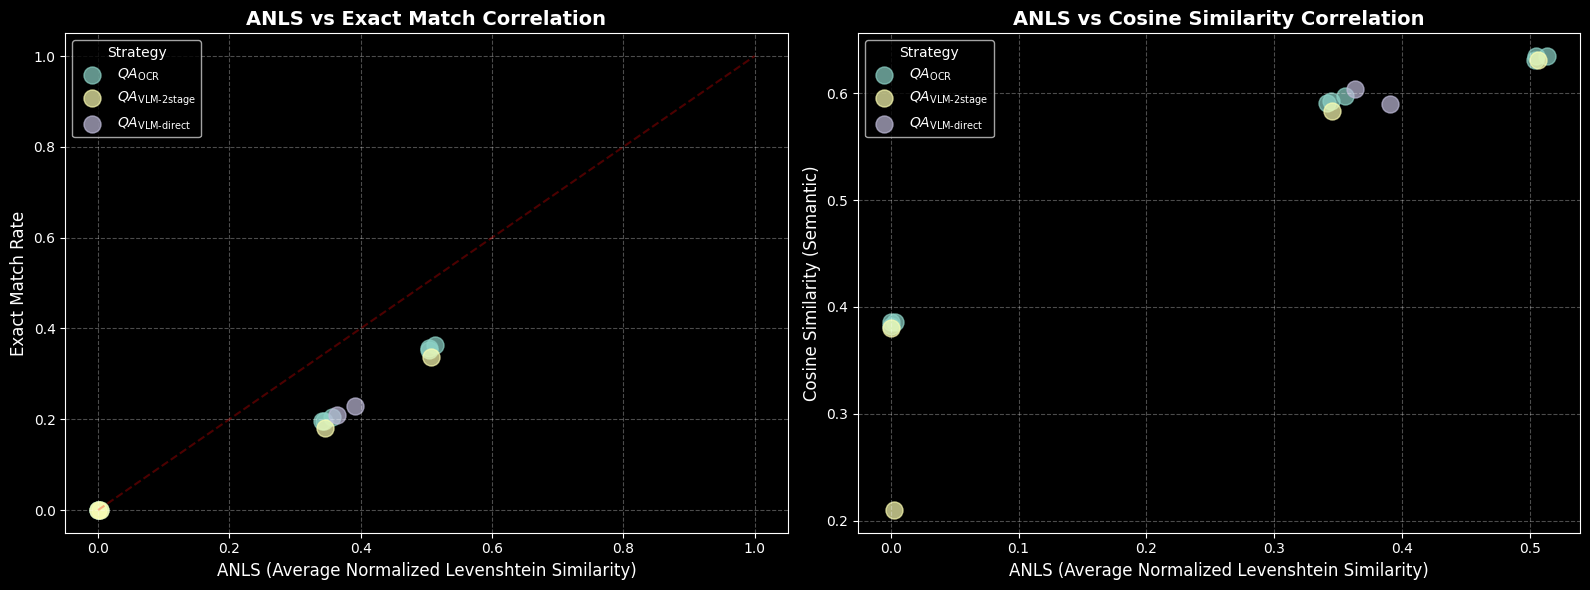

In [19]:
# Scatter plots: ANLS vs other metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANLS vs Exact Match
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['ANLS'], strategy_data['Exact Match'],
                s=150, alpha=0.7, label=strategy)
ax1.set_title('ANLS vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax1.set_ylabel('Exact Match Rate', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')
ax1.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='ANLS=EM')

# ANLS vs Cosine Similarity
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['ANLS'], strategy_data['Cosine Similarity'],
                s=150, alpha=0.7, label=strategy)
ax2.set_title('ANLS vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax2.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/var/folders/g9/llcmfs150lg102rht49jlz980000gq/T/ipykernel_44647/501641545.py:60: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


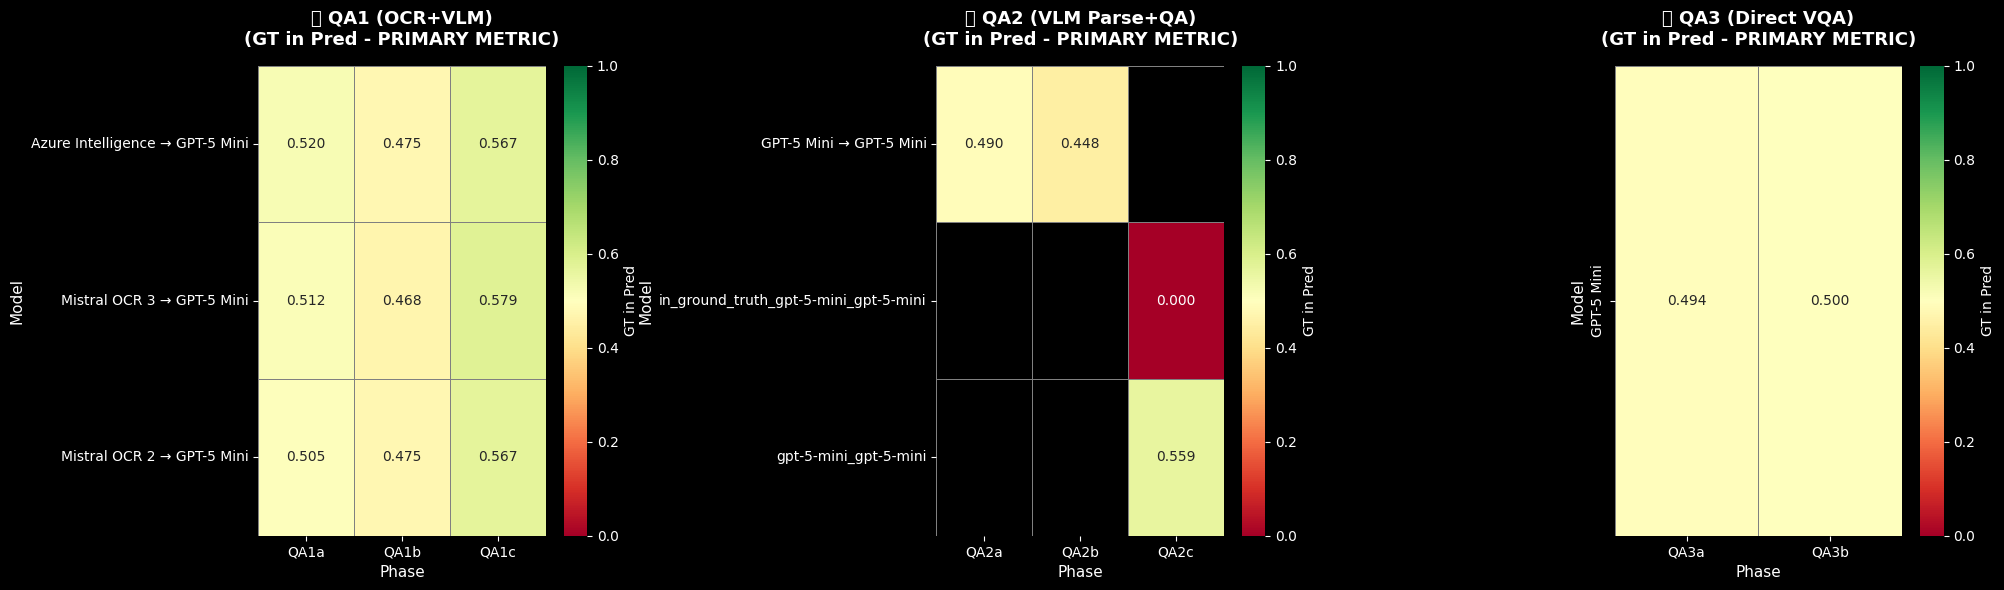


🎯 PRIMARY METRIC HEATMAPS: GT in Pred (Ground Truth in Prediction)

Interpretation:
  - Green cells: High performance (GT found in prediction)
  - Red cells: Low performance (GT not found in prediction)
  - Values closer to 1.0 indicate better performance


In [23]:
# Define phase_groups for strategy analysis
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

# Create comprehensive heatmap visualization for GT in Pred across all strategies
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (strategy_name, phases) in enumerate(phase_groups.items()):
    ax = axes[idx]
    
    # Filter phases for this strategy
    strategy_phase_names = [p for p in phases if p in metrics_results]
    if not strategy_phase_names:
        print(f"⚠️ No phases found for {strategy_name}")
        continue
    
    # Create heatmap data: rows = models, columns = phases in this strategy
    heatmap_data = []
    model_names = []
    
    # Get all unique models across the phases in this strategy
    all_models = set()
    for phase in strategy_phase_names:
        if phase in metrics_results:
            all_models.update(metrics_results[phase].keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in strategy_phase_names:
            if phase in metrics_results and model in metrics_results[phase]:
                value = metrics_results[phase][model].get('gt_in_pred', np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=strategy_phase_names
    )
    
    # Create heatmap with primary metric styling
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=ax, cbar_kws={'label': 'GT in Pred'}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    ax.set_title(f'🎯 {strategy_name}\n(GT in Pred - PRIMARY METRIC)', 
                fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Phase', fontsize=11)
    ax.set_ylabel('Model', fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "="*120)
print("🎯 PRIMARY METRIC HEATMAPS: GT in Pred (Ground Truth in Prediction)")
print("="*120)
print("\nInterpretation:")
print("  - Green cells: High performance (GT found in prediction)")
print("  - Red cells: Low performance (GT not found in prediction)")
print("  - Values closer to 1.0 indicate better performance")

## 10.5 Ground Truth in Parsed Data Analysis

Heatmap visualization for "Ground Truth in Parsed Data" metric across all experiments.


GROUND TRUTH IN PARSED DATA - Comprehensive Analysis

This metric measures whether ground truth answers appear in parsed/extracted text.
High values indicate strong parsing effectiveness. We analyze this vs QA performance metrics.


--- Part 1: Heatmap Visualizations ---


Ground Truth in Parsed Data - $QA_{\text{OCR}}$

Ground Truth in Parsed Data - $QA_{\text{OCR}}$:


,QA1a,QA1b,QA1c
Azure Intelligence → GPT-5 Mini,0.504950,0.504950,0.504950
Mistral OCR 3 → GPT-5 Mini,0.391089,0.386139,0.391089
Mistral OCR 2 → GPT-5 Mini,0.467822,0.470297,0.457921


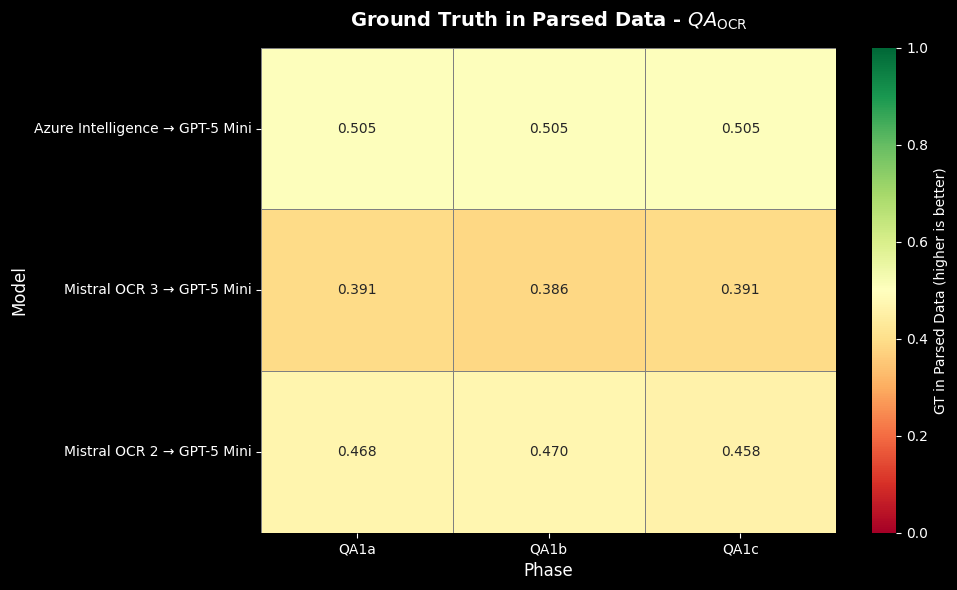


Ground Truth in Parsed Data - $QA_{\text{VLM-2stage}}$

Ground Truth in Parsed Data - $QA_{\text{VLM-2stage}}$:


,QA2a,QA2b,QA2c
GPT-5 Mini → GPT-5 Mini,0.465347,0.492574,NaN
in_ground_truth_gpt-5-mini_gpt-5-mini,NaN,NaN,0.000000
gpt-5-mini_gpt-5-mini,NaN,NaN,0.487624


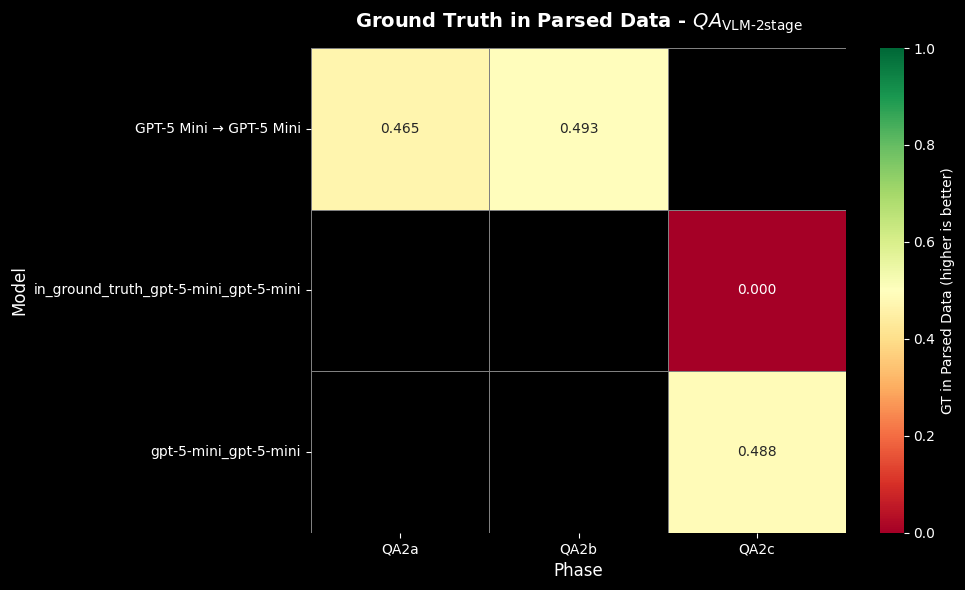


Ground Truth in Parsed Data - $QA_{\text{VLM-direct}}$

Ground Truth in Parsed Data - $QA_{\text{VLM-direct}}$:


,QA3a,QA3b
GPT-5 Mini,0.0,0.0


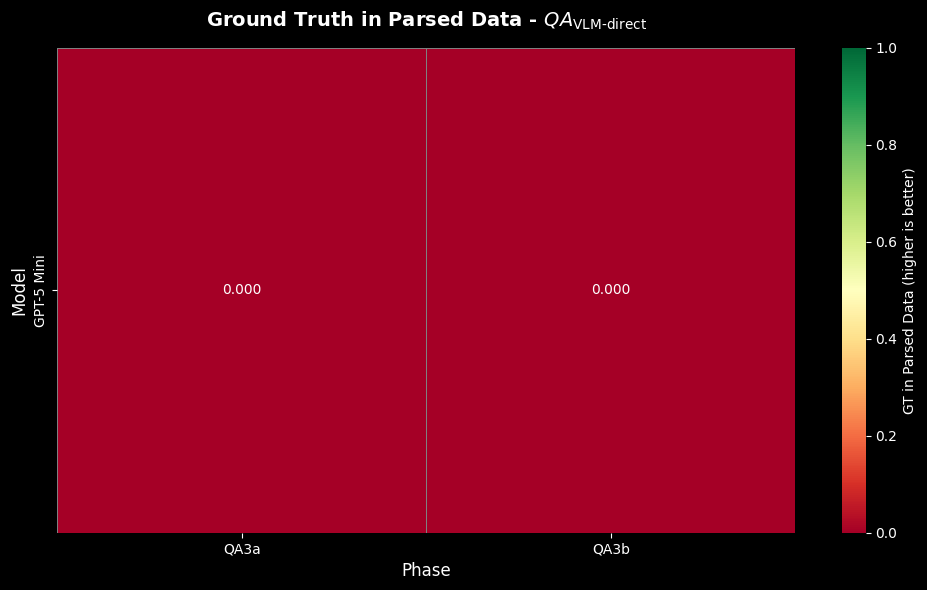



--- Part 2: Regression Analysis ---

$QA_{\text{OCR}}$:
  Regression: y = -0.0179x + 0.5268
  R² = 0.0004, Pearson r = -0.0211, p-value = 0.957042
$QA_{\text{VLM-2stage}}$:
  Regression: y = 1.0332x + 0.0010
  R² = 0.9644, Pearson r = 0.9820, p-value = 0.017974
$QA_{\text{VLM-direct}}$: ⚠️ Insufficient data variance for regression (n=2, std_x=0.0000)


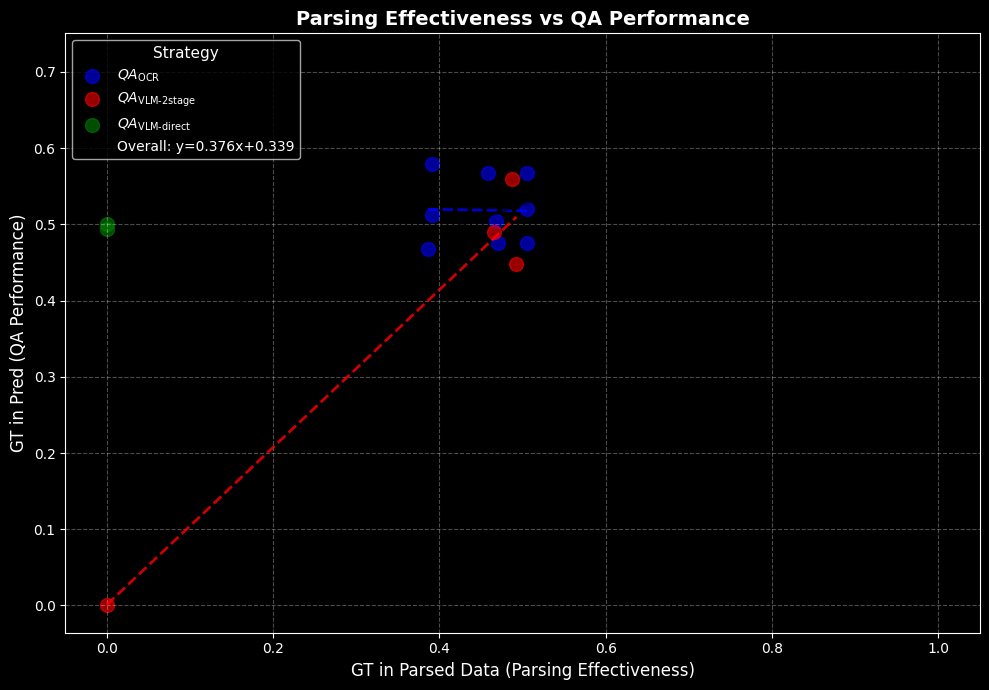

$QA_{\text{OCR}}$:
  ANLS Regression: y = 0.1530x + 0.2157
  R² = 0.0012, Pearson r = 0.0348, p-value = 0.929156
$QA_{\text{VLM-2stage}}$:
  ANLS Regression: y = 0.5801x + 0.0039
  R² = 0.3043, Pearson r = 0.5516, p-value = 0.448353
$QA_{\text{VLM-direct}}$: ⚠️ Insufficient data variance for ANLS regression


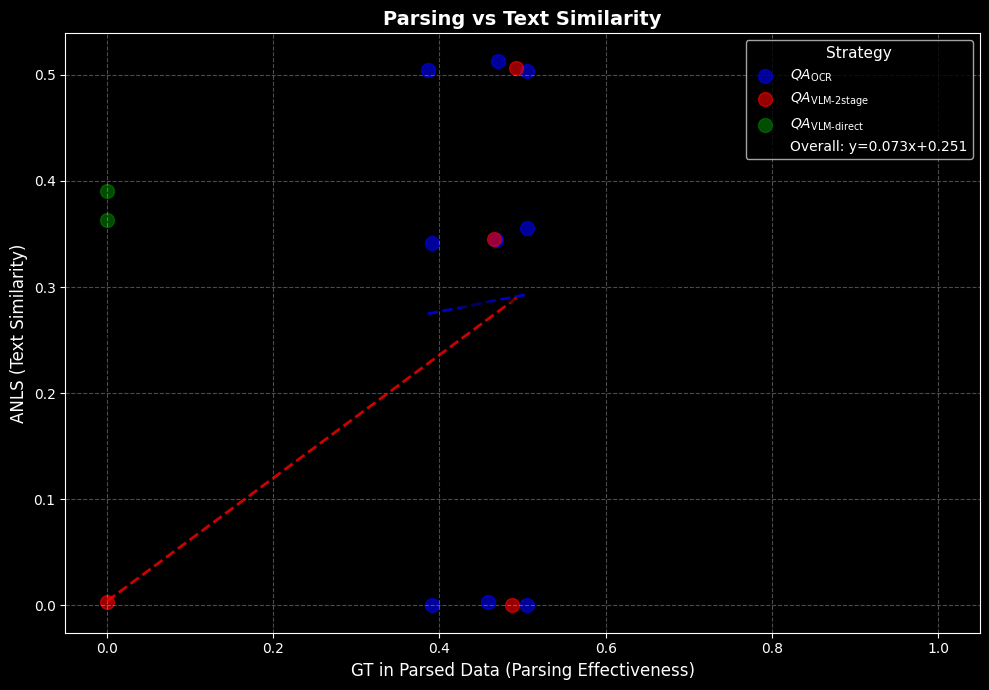


INTERPRETATION GUIDE

• High R² values (>0.5) indicate strong linear relationship between parsing and QA performance
• Positive slopes suggest: better parsing → better QA results
• Steep slopes mean parsing improvements significantly boost QA performance
• Low p-values (<0.05) indicate statistically significant relationships
• Comparison helps identify: Is parsing or LLM QA the bottleneck?
• ⚠️ If regression fails, it may indicate all GT in Parsed Data values are 0 or identical



In [22]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
print("GROUND TRUTH IN PARSED DATA - Comprehensive Analysis")
print("="*120)
print("\nThis metric measures whether ground truth answers appear in parsed/extracted text.")
print("High values indicate strong parsing effectiveness. We analyze this vs QA performance metrics.\n")

# Auto-detect strategy groups from available phases
has_qa4 = any('QA4' in phase for phase in metrics_results.keys())

strategy_groups = {
    '$QA_{\\text{OCR}}$': ['QA1a', 'QA1b', 'QA1c'],
    '$QA_{\\text{VLM-2stage}}$': ['QA2a', 'QA2b', 'QA2c'],
    '$QA_{\\text{VLM-direct}}$': ['QA3a', 'QA3b']
}

if has_qa4:
    strategy_groups['$QA_{\\text{special}}$'] = ['QA4a', 'QA4b', 'QA4c']

# Color mapping for strategies
strategy_colors = {
    '$QA_{\\text{OCR}}$': 'blue',
    '$QA_{\\text{VLM-2stage}}$': 'red',
    '$QA_{\\text{VLM-direct}}$': 'green',
    '$QA_{\\text{special}}$': 'orange'
}

def can_fit_regression(x_vals, y_vals, min_points=3):
    """Check if we can safely perform linear regression."""
    if len(x_vals) < min_points or len(y_vals) < min_points:
        return False
    # Check for variance in x values (can't fit if all x are the same)
    if np.std(x_vals) < 1e-10:
        return False
    # Check for any NaN or infinite values
    if any(np.isnan(x_vals)) or any(np.isnan(y_vals)):
        return False
    if any(np.isinf(x_vals)) or any(np.isinf(y_vals)):
        return False
    return True

# ============================================================================
# Part 1: Heatmap Visualizations
# ============================================================================
print("\n--- Part 1: Heatmap Visualizations ---\n")

for strategy_name, phases in strategy_groups.items():
    print(f"\n{'='*80}")
    print(f"Ground Truth in Parsed Data - {strategy_name}")
    print(f"{'='*80}")
    
    # Filter phases for this strategy
    strategy_phase_names = [p for p in phases if p in metrics_results]
    if not strategy_phase_names:
        print(f"⚠️ No phases found for {strategy_name}")
        continue
    
    # Create heatmap data: rows = models, columns = phases in this strategy
    heatmap_data = []
    model_names = []
    
    # Get all unique models across the phases in this strategy
    all_models = set()
    for phase in strategy_phase_names:
        if phase in metrics_results:
            all_models.update(metrics_results[phase].keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in strategy_phase_names:
            if phase in metrics_results and model in metrics_results[phase]:
                value = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=strategy_phase_names
    )
    
    # Print the table
    print(f"\nGround Truth in Parsed Data - {strategy_name}:")
    display(heatmap_df)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Use colormap: green for good, red for bad
    cmap = 'RdYlGn'
    cbar_label = 'GT in Parsed Data (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    ax.set_title(f'Ground Truth in Parsed Data - {strategy_name}', 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# Part 2: Regression Analysis - GT in Parsed Data vs GT in Pred
# ============================================================================
print("\n\n--- Part 2: Regression Analysis ---\n")

# Scatter plot 1: GT in Parsed Data vs GT in Pred
fig1, ax1 = plt.subplots(figsize=(10, 7))
x_vals_all = []
y_vals_all = []

for strategy_name in strategy_groups.keys():
    x_vals = []
    y_vals = []
    
    for phase in strategy_groups[strategy_name]:
        if phase in metrics_results:
            for model in metrics_results[phase]:
                gt_parsed = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                gt_pred = metrics_results[phase][model].get('gt_in_pred', np.nan)
                
                if not np.isnan(gt_parsed) and not np.isnan(gt_pred):
                    x_vals.append(gt_parsed)
                    y_vals.append(gt_pred)
    
    if x_vals:
        x_vals_all.extend(x_vals)
        y_vals_all.extend(y_vals)
        
        # Plot points
        ax1.scatter(x_vals, y_vals, s=100, alpha=0.6, 
                   label=strategy_name, color=strategy_colors.get(strategy_name, 'gray'))
        
        # Linear regression for this strategy (only if we have enough valid data)
        if can_fit_regression(x_vals, y_vals):
            try:
                z = np.polyfit(x_vals, y_vals, 1)
                p = np.poly1d(z)
                x_line = np.linspace(min(x_vals), max(x_vals), 100)
                y_line = p(x_line)
                ax1.plot(x_line, y_line, color=strategy_colors.get(strategy_name, 'gray'), 
                        linestyle='--', linewidth=2, alpha=0.8)
                
                # Calculate statistics
                slope, intercept = z[0], z[1]
                r_value, p_value = stats.pearsonr(x_vals, y_vals)
                r_squared = r_value ** 2
                
                print(f"{strategy_name}:")
                print(f"  Regression: y = {slope:.4f}x + {intercept:.4f}")
                print(f"  R² = {r_squared:.4f}, Pearson r = {r_value:.4f}, p-value = {p_value:.6f}")
            except Exception as e:
                print(f"{strategy_name}: ⚠️ Could not fit regression ({e})")
        else:
            print(f"{strategy_name}: ⚠️ Insufficient data variance for regression (n={len(x_vals)}, std_x={np.std(x_vals):.4f})")

ax1.set_xlabel('GT in Parsed Data (Parsing Effectiveness)', fontsize=12)
ax1.set_ylabel('GT in Pred (QA Performance)', fontsize=12)
ax1.set_title('Parsing Effectiveness vs QA Performance', fontsize=14, fontweight='bold')
ax1.legend(title='Strategy', fontsize=10, title_fontsize=11)
ax1.grid(alpha=0.3, linestyle='--')

# Overall linear fit
if can_fit_regression(x_vals_all, y_vals_all):
    try:
        z_all = np.polyfit(x_vals_all, y_vals_all, 1)
        p_all = np.poly1d(z_all)
        x_line_all = np.linspace(0, 1, 100)
        y_line_all = p_all(x_line_all)
        ax1.plot(x_line_all, y_line_all, 'k-', linewidth=2.5, alpha=0.5, label=f'Overall: y={z_all[0]:.3f}x+{z_all[1]:.3f}')
        ax1.legend(title='Strategy', fontsize=10, title_fontsize=11)
    except Exception as e:
        print(f"Overall regression failed: {e}")

plt.tight_layout()
plt.show()

# Scatter plot 2: GT in Parsed Data vs ANLS
fig2, ax2 = plt.subplots(figsize=(10, 7))
x_vals_all = []
y_vals_all = []

for strategy_name in strategy_groups.keys():
    x_vals = []
    y_vals = []
    
    for phase in strategy_groups[strategy_name]:
        if phase in metrics_results:
            for model in metrics_results[phase]:
                gt_parsed = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                anls = metrics_results[phase][model].get('anls', np.nan)
                
                if not np.isnan(gt_parsed) and not np.isnan(anls):
                    x_vals.append(gt_parsed)
                    y_vals.append(anls)
    
    if x_vals:
        x_vals_all.extend(x_vals)
        y_vals_all.extend(y_vals)
        
        # Plot points
        ax2.scatter(x_vals, y_vals, s=100, alpha=0.6, 
                   label=strategy_name, color=strategy_colors.get(strategy_name, 'gray'))
        
        # Linear regression for this strategy (only if we have enough valid data)
        if can_fit_regression(x_vals, y_vals):
            try:
                z = np.polyfit(x_vals, y_vals, 1)
                p = np.poly1d(z)
                x_line = np.linspace(min(x_vals), max(x_vals), 100)
                y_line = p(x_line)
                ax2.plot(x_line, y_line, color=strategy_colors.get(strategy_name, 'gray'), 
                        linestyle='--', linewidth=2, alpha=0.8)
                
                # Calculate statistics
                slope, intercept = z[0], z[1]
                r_value, p_value = stats.pearsonr(x_vals, y_vals)
                r_squared = r_value ** 2
                
                print(f"{strategy_name}:")
                print(f"  ANLS Regression: y = {slope:.4f}x + {intercept:.4f}")
                print(f"  R² = {r_squared:.4f}, Pearson r = {r_value:.4f}, p-value = {p_value:.6f}")
            except Exception as e:
                print(f"{strategy_name}: ⚠️ Could not fit ANLS regression ({e})")
        else:
            print(f"{strategy_name}: ⚠️ Insufficient data variance for ANLS regression")

ax2.set_xlabel('GT in Parsed Data (Parsing Effectiveness)', fontsize=12)
ax2.set_ylabel('ANLS (Text Similarity)', fontsize=12)
ax2.set_title('Parsing vs Text Similarity', fontsize=14, fontweight='bold')
ax2.legend(title='Strategy', fontsize=10, title_fontsize=11)
ax2.grid(alpha=0.3, linestyle='--')

# Overall linear fit
if can_fit_regression(x_vals_all, y_vals_all):
    try:
        z_all = np.polyfit(x_vals_all, y_vals_all, 1)
        p_all = np.poly1d(z_all)
        x_line_all = np.linspace(0, 1, 100)
        y_line_all = p_all(x_line_all)
        ax2.plot(x_line_all, y_line_all, 'k-', linewidth=2.5, alpha=0.5, label=f'Overall: y={z_all[0]:.3f}x+{z_all[1]:.3f}')
        ax2.legend(title='Strategy', fontsize=10, title_fontsize=11)
    except Exception as e:
        print(f"Overall ANLS regression failed: {e}")

plt.tight_layout()
plt.show()

print("\n" + "="*120)
print("INTERPRETATION GUIDE")
print("="*120)
print("""
• High R² values (>0.5) indicate strong linear relationship between parsing and QA performance
• Positive slopes suggest: better parsing → better QA results
• Steep slopes mean parsing improvements significantly boost QA performance
• Low p-values (<0.05) indicate statistically significant relationships
• Comparison helps identify: Is parsing or LLM QA the bottleneck?
• ⚠️ If regression fails, it may indicate all GT in Parsed Data values are 0 or identical
""")

## 11. QA-Specific Analysis

Analyze question types, answer lengths, and QA-specific patterns.


Question Type Distribution (QA1a):
  What           :  239 questions ( 59.2%)
  How            :   54 questions ( 13.4%)
  Yes/No         :   29 questions (  7.2%)
  Who            :   25 questions (  6.2%)
  Other          :   25 questions (  6.2%)
  Which          :   18 questions (  4.5%)
  When           :    9 questions (  2.2%)
  Where          :    5 questions (  1.2%)


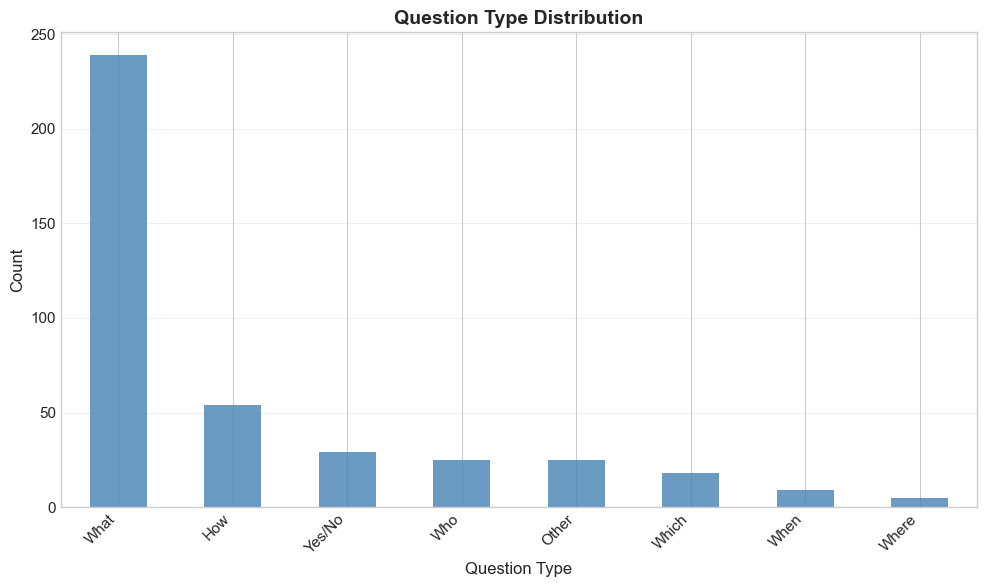

In [ ]:
# Question type analysis
if len(phase_dfs) > 0:
    # Use first available phase for analysis
    analysis_phase = list(phase_dfs.keys())[0]
    df_analysis = phase_dfs[analysis_phase].copy()
    
    # Add question type categorization
    df_analysis['question_type'] = df_analysis['question'].apply(categorize_question_type)
    
    print(f"\nQuestion Type Distribution ({analysis_phase}):")
    print("=" * 80)
    type_counts = df_analysis['question_type'].value_counts()
    for qtype, count in type_counts.items():
        pct = count / len(df_analysis) * 100
        print(f"  {qtype:15s}: {count:4d} questions ({pct:5.1f}%)")
    
    # Visualize question types
    fig, ax = plt.subplots(figsize=(10, 6))
    type_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title('Question Type Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

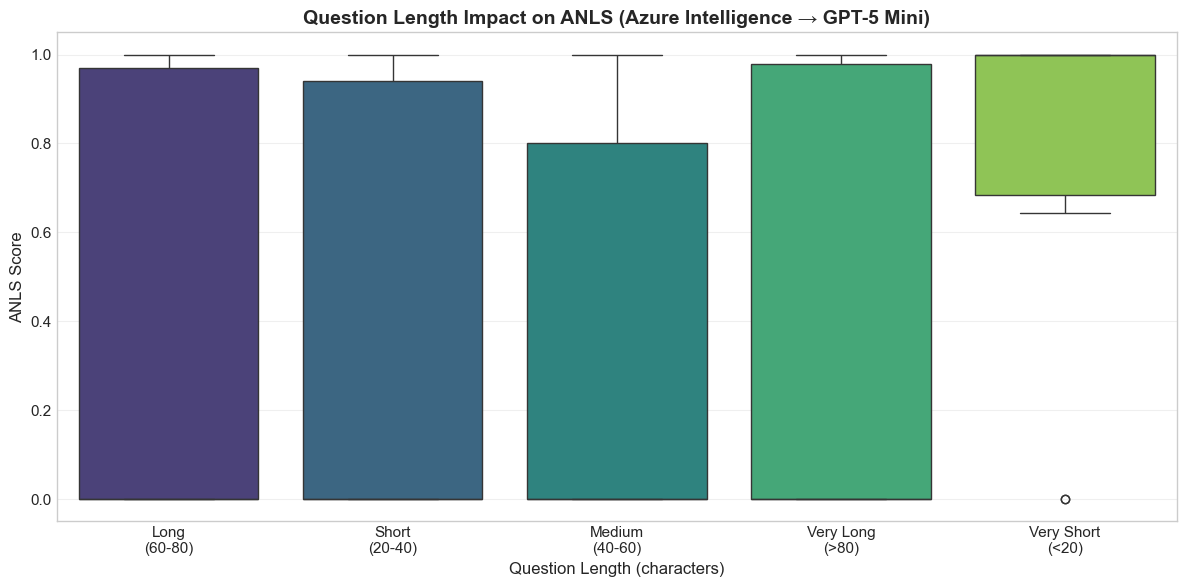

In [ ]:
# Question length impact on performance
if len(phase_dfs) > 0:
    df_analysis['question_length'] = df_analysis['question'].astype(str).str.len()
    df_analysis['question_length_bin'] = pd.cut(
        df_analysis['question_length'],
        bins=[0, 20, 40, 60, 80, 1000],
        labels=['Very Short\n(<20)', 'Short\n(20-40)', 'Medium\n(40-60)', 'Long\n(60-80)', 'Very Long\n(>80)']
    )
    
    # Calculate ANLS for first model per length bin
    pred_col = [col for col in df_analysis.columns if col.startswith('prediction_')][0]
    model_name = pred_col.replace('prediction_', '')
    
    anls_by_length = []
    for _, row in df_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[pred_col]), ground_truths, threshold=0.5)
        anls_by_length.append({
            'question_length_bin': row['question_length_bin'],
            'anls': anls
        })
    
    anls_length_df = pd.DataFrame(anls_by_length)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')
    ax.set_title(f'Question Length Impact on ANLS ({get_model_display_name(model_name)})', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Length (characters)', fontsize=12)
    ax.set_ylabel('ANLS Score', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 12. Phase Comparison Analysis

Compare the three QA strategies: OCR+VLM, VLM Parse+QA, and Direct VQA.

In [ ]:
strategy_results = []
for group_name, phases in phase_groups.items():
    # Filter by Phase column (QA1a, QA1b, etc.), not Strategy column
    group_data = summary_df[summary_df['Phase'].isin(phases)]
    if len(group_data) > 0:
        avg_gt_in_pred = group_data['GT in Pred'].mean()
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  🎯 Mean GT in Pred: {avg_gt_in_pred:.4f} [PRIMARY]")
        print(f"     Mean ANLS: {avg_anls:.4f}")
        print(f"     Mean Exact Match: {avg_em:.4f}")
        print(f"     Mean Substring Match: {avg_substring:.4f}")
        print(f"  Phases included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'GT in Pred': avg_gt_in_pred,  # PRIMARY FIRST
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })
    else:
        print(f"\n⚠️ {group_name}: No data found for phases {phases}")

NameError: name 'phase_groups' is not defined

## 13. Sample-Level Error Analysis

Identify easiest and hardest questions to understand error patterns.

In [ ]:
# Analyze best and worst performing samples
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_error_analysis = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_error_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate ANLS for each sample
    anls_scores = []
    for _, row in df_error_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[f'prediction_{first_model}']), ground_truths, threshold=0.5)
        anls_scores.append(anls)
    
    df_error_analysis['anls'] = anls_scores
    
    # Get best and worst samples
    best_samples = df_error_analysis.nlargest(10, 'anls')
    worst_samples = df_error_analysis.nsmallest(10, 'anls')
    
    print("\n" + "="*120)
    print(f"EASIEST QUESTIONS (Highest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")
    
    print("\n" + "="*120)
    print(f"HARDEST QUESTIONS (Lowest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")


EASIEST QUESTIONS (Highest ANLS) - Model: Azure Intelligence → GPT-5 Mini

Sample: 06cc755612621483103dd1752c3927f7_20bc915e220e460a539fb622f1085943 | ANLS: 1.0000
Question: Who is the RIT Men's Hockey team playing against October 28?
Ground Truths: "Notre Dame"
Prediction: Notre Dame

Sample: 098bda18540fa5e097196c3f7898d4f1_c55543406c7e546faafb9246d0fff991 | ANLS: 1.0000
Question: How many people are there in the two pictures with the subtitle Taste Test on the first page?
Ground Truths: "4"
Prediction: 4

Sample: 09a039762a17ef85fbe52be984e62740_fbf54b9254d8e59ffb90f1972763545a | ANLS: 1.0000
Question: WHAT IS THE EXPAND OF ISS?
Ground Truths: "INTERNATIONAL SPACE STATION"
Prediction: International Space Station

Sample: 0afbb63ded89d3335a5109f8a9ec4db7_a19fd127268fb9493257f12d53d5d53d | ANLS: 1.0000
Question: According to the American Rescue Plan, what was the percentage of unemployment in New York prior to ...
Ground Truths: "3.9%"
Prediction: 3.9%

Sample: 0afbb63ded89d3335a5109

## 14. Inference Time Analysis

Analyze speed vs accuracy trade-offs.


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms),Strategy
1,QA1a,mistral_document_ai__gpt-5-mini,10987.070182,9023.925185,QA1 (OCR+VLM)
0,QA1a,azure_intelligence__gpt-5-mini,14108.144354,11151.789546,QA1 (OCR+VLM)
3,QA1b,mistral_document_ai__gpt-5-mini,10457.573617,8888.805985,QA1 (OCR+VLM)
2,QA1b,azure_intelligence__gpt-5-mini,12987.485448,10167.797565,QA1 (OCR+VLM)
5,QA1c,mistral_document_ai__gpt-5-mini,13864.428838,12103.630424,QA1 (OCR+VLM)
4,QA1c,azure_intelligence__gpt-5-mini,17644.109300,11987.199903,QA1 (OCR+VLM)
6,QA2a,gpt-5-mini__gpt-5-mini,25036.871067,22526.462555,QA2 (VLM Parse+QA)
7,QA2b,gpt-5-mini__gpt-5-mini,23580.006194,21973.999977,QA2 (VLM Parse+QA)
8,QA2c,gpt-5-mini_gpt-5-mini,25521.843176,23721.717954,QA2 (VLM Parse+QA)
9,QA3a,gpt-5-mini,6892.738389,6021.960855,QA3 (Direct VQA)


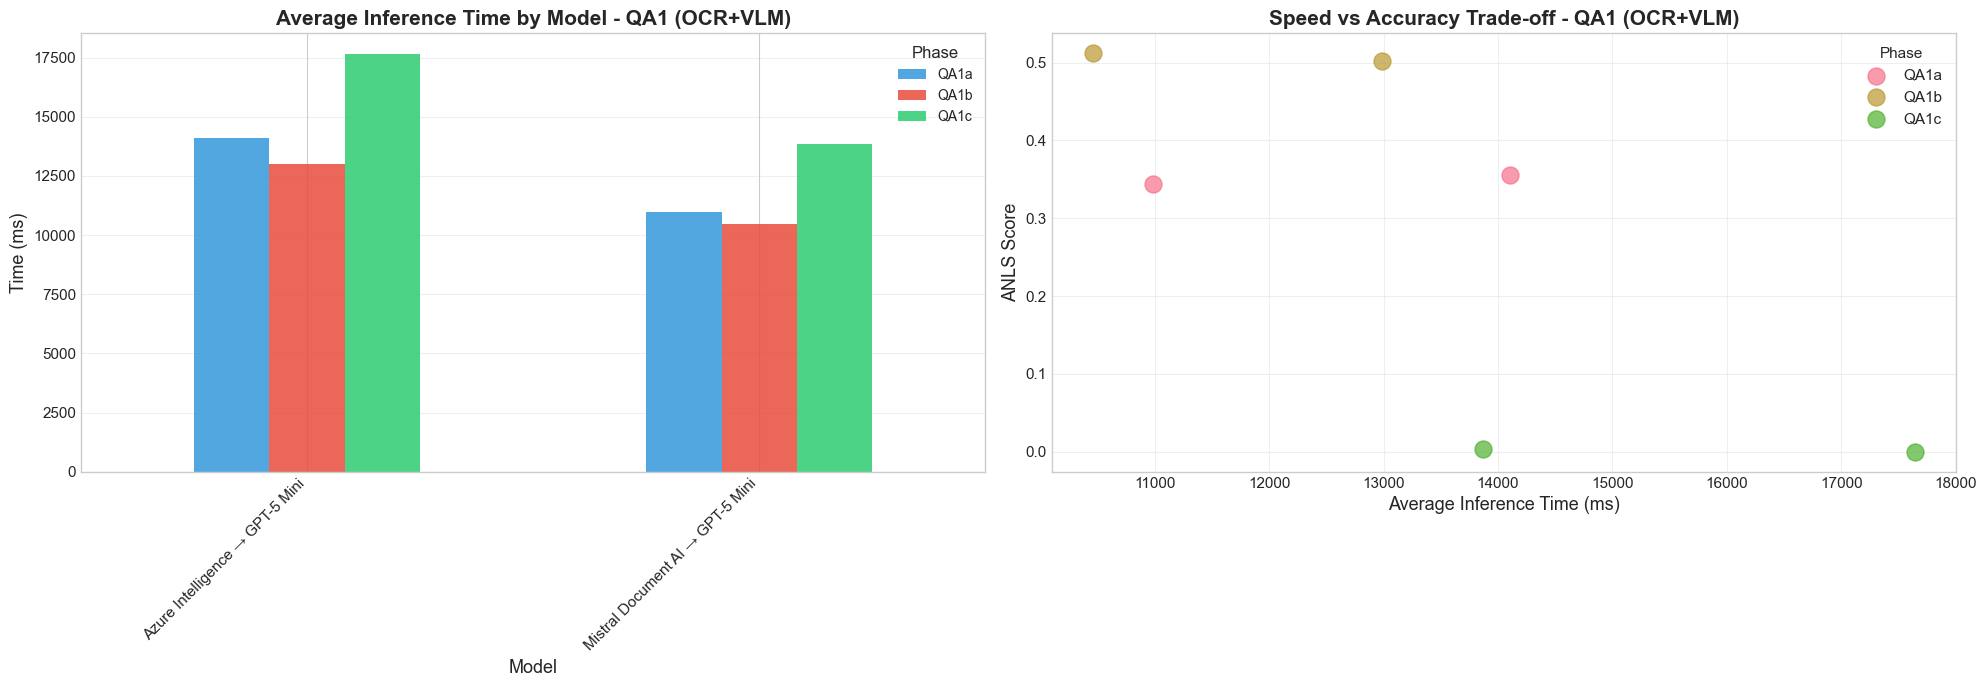

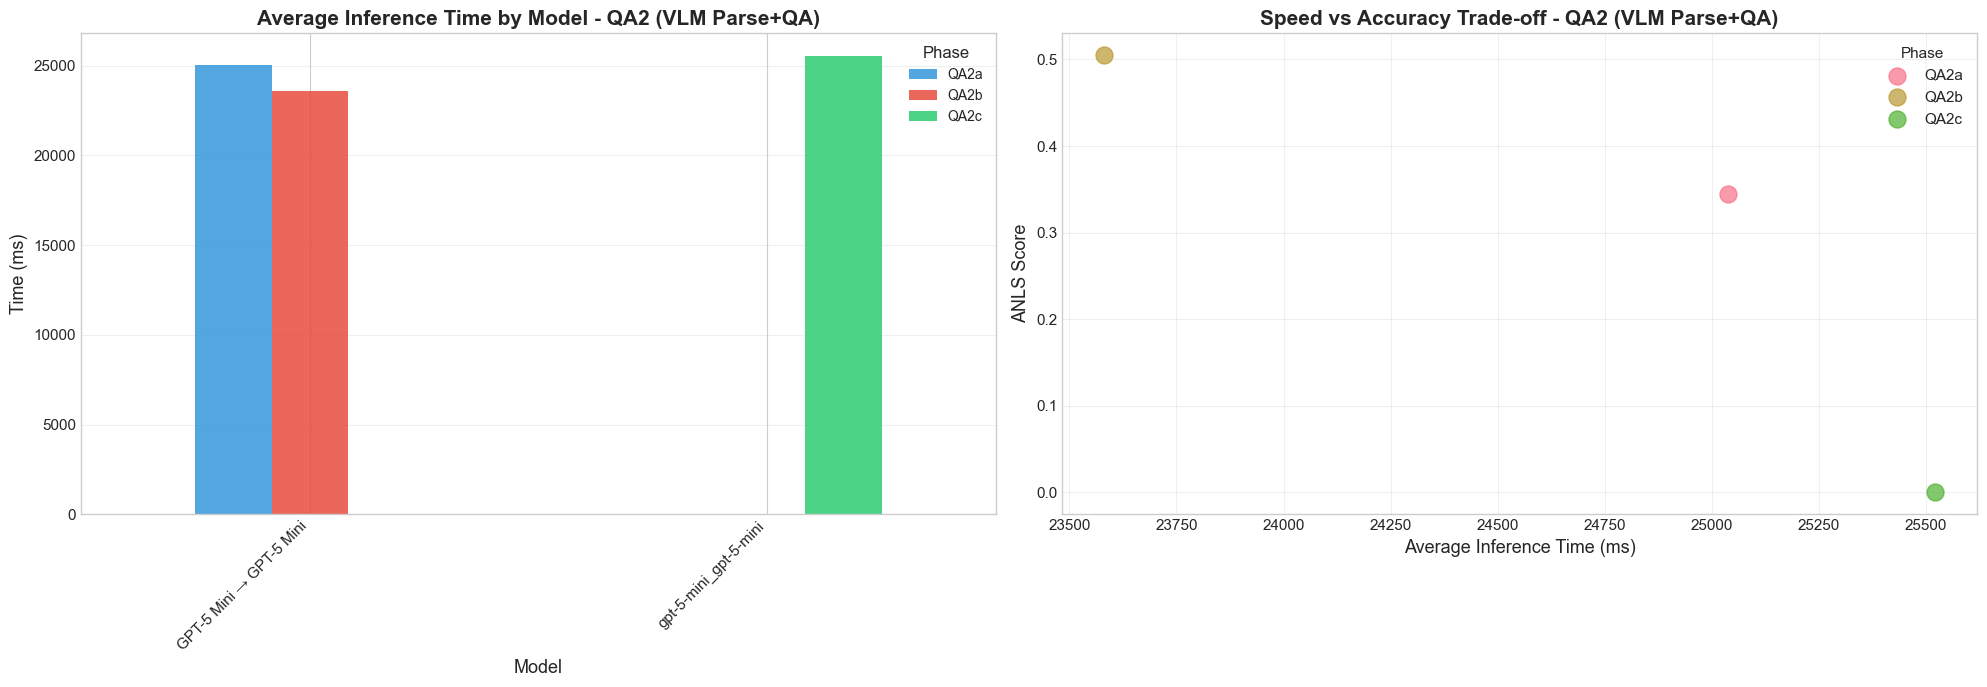

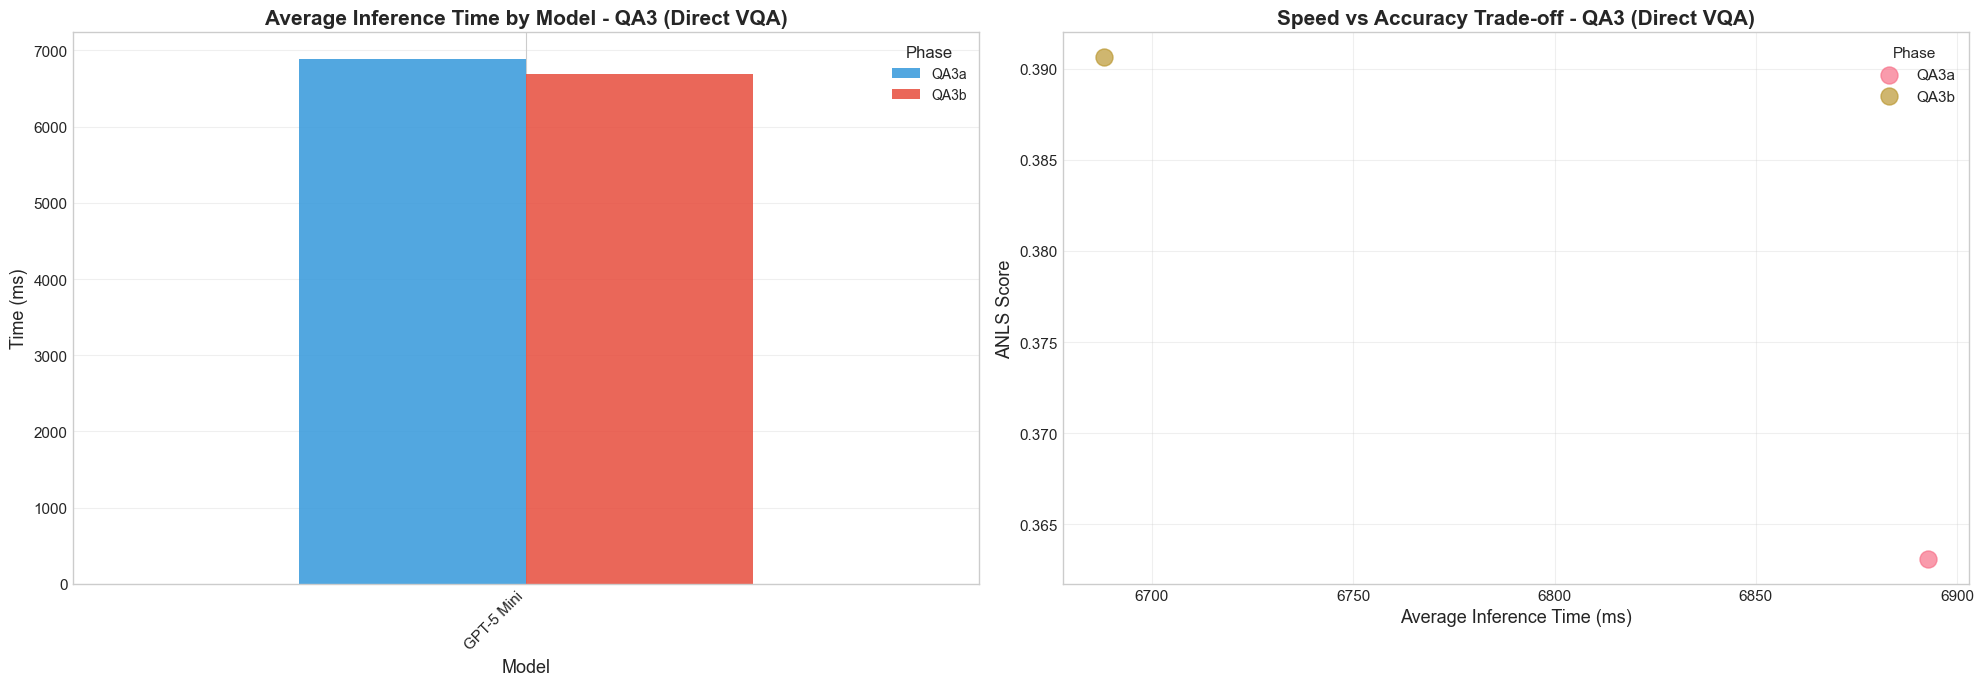

In [ ]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    inference_df['Strategy'] = inference_df['Phase'].apply(get_phase_strategy)
    
    print("\nInference Time Summary:")
    print("="*120)
    display(inference_df.sort_values(['Strategy', 'Phase', 'Mean Time (ms)']))
    
    # Define color palette
    colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
    
    # Define strategies
    strategies = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
    
    # Visualization: one graph per QA strategy
    for strategy in strategies:
        strategy_inference = inference_df[inference_df['Strategy'] == strategy]
        if strategy_inference.empty:
            continue
        
        fig, axes = plt.subplots(1, 2, figsize=(20, 7))
        
        # Bar chart for inference time
        ax1 = axes[0]
        pivot_time = strategy_inference.pivot(index='Model', columns='Phase', values='Mean Time (ms)')
        pivot_time = pivot_time.reindex(sort_models(pivot_time.index.tolist()))
        pivot_time.plot(kind='bar', ax=ax1, color=colors_palette[:len(pivot_time.columns)], alpha=0.85)
        
        ax1.set_title(f'Average Inference Time by Model - {strategy}', fontsize=15, fontweight='bold')
        ax1.set_xlabel('Model', fontsize=13)
        ax1.set_ylabel('Time (ms)', fontsize=13)
        ax1.legend(title='Phase', title_fontsize=12, fontsize=10, loc='best')
        ax1.grid(axis='y', alpha=0.3)
        ax1.set_xticklabels([get_model_display_name(t.get_text()) for t in ax1.get_xticklabels()], 
                           rotation=45, ha='right')
        
        # Speed vs Accuracy scatter plot
        ax2 = axes[1]
        
        # Merge inference time with ANLS scores for this strategy
        strategy_summary = summary_df[summary_df['Strategy'] == strategy]
        speed_accuracy = pd.merge(
            strategy_inference[['Phase', 'Model', 'Mean Time (ms)']],
            strategy_summary[['Phase', 'Model', 'ANLS']],
            on=['Phase', 'Model']
        )
        
        for phase in speed_accuracy['Phase'].unique():
            phase_data = speed_accuracy[speed_accuracy['Phase'] == phase]
            ax2.scatter(phase_data['Mean Time (ms)'], phase_data['ANLS'], 
                       s=150, alpha=0.7, label=phase)
        
        ax2.set_title(f'Speed vs Accuracy Trade-off - {strategy}', fontsize=15, fontweight='bold')
        ax2.set_xlabel('Average Inference Time (ms)', fontsize=13)
        ax2.set_ylabel('ANLS Score', fontsize=13)
        ax2.legend(title='Phase', loc='best')
        ax2.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("No inference time data available")

## 15. DUDE-Specific Analysis

Analyze DUDE dataset-specific patterns: document complexity, layout understanding, and multi-page reasoning.

In [ ]:
# Analyze performance on DUDE-specific challenges
print("\nDUDE-Specific Analysis:")
print("=" * 100)
print("\nDataset Characteristics:")
print("- DUDE (Document Understanding Dataset) focuses on complex, multi-page documents")
print("- Tests models on challenging real-world document scenarios")
print("- Requires reasoning across document layouts and structures")
print("- Evaluates multi-page reasoning capabilities")

print("\nKey Findings:")
print("- Complex document understanding requires both OCR accuracy and layout comprehension")
print("- Multi-page documents present unique challenges for context management")
print("- Structured document parsing benefits from specialized document AI models")

print("\nRecommendations:")
print("- For complex multi-page documents: Consider hybrid OCR+VLM approach (QA1)")
print("- For layout-heavy documents: VLM Parse+QA (QA2) can capture visual structure")
print("- For quick extraction: Direct VQA (QA3) may sacrifice accuracy for speed")
print("- Note: QA2c (Claude Sonnet) has large file size (56MB) - optimize memory if needed")

print("\nPerformance Patterns on Complex Documents:")
if len(summary_df) > 0:
    # Analyze which strategy works best for DUDE
    qa1_perf = summary_df[summary_df['Phase'].str.startswith('QA1')]['GT in Pred'].mean()
    qa2_perf = summary_df[summary_df['Phase'].str.startswith('QA2')]['GT in Pred'].mean()
    qa3_perf = summary_df[summary_df['Phase'].str.startswith('QA3')]['GT in Pred'].mean()
    
    print(f"  QA1 (OCR+VLM) average GT in Pred: {qa1_perf:.4f}")
    print(f"  QA2 (VLM Parse+QA) average GT in Pred: {qa2_perf:.4f}")
    print(f"  QA3 (Direct VQA) average GT in Pred: {qa3_perf:.4f}")
    
    best_strategy = max(
        [('QA1 (OCR+VLM)', qa1_perf), ('QA2 (VLM Parse+QA)', qa2_perf), ('QA3 (Direct VQA)', qa3_perf)],
        key=lambda x: x[1]
    )
    print(f"\n  🏆 Best performing strategy for DUDE: {best_strategy[0]} ({best_strategy[1]:.4f})")


DUDE-Specific Analysis:

Dataset Characteristics:
- DUDE (Document Understanding Dataset) focuses on complex, multi-page documents
- Tests models on challenging real-world document scenarios
- Requires reasoning across document layouts and structures
- Evaluates multi-page reasoning capabilities

Key Findings:
- Complex document understanding requires both OCR accuracy and layout comprehension
- Multi-page documents present unique challenges for context management
- Structured document parsing benefits from specialized document AI models

Recommendations:
- For complex multi-page documents: Consider hybrid OCR+VLM approach (QA1)
- For layout-heavy documents: VLM Parse+QA (QA2) can capture visual structure
- For quick extraction: Direct VQA (QA3) may sacrifice accuracy for speed
- Note: QA2c (Claude Sonnet) has large file size (56MB) - optimize memory if needed

Performance Patterns on Complex Documents:
  QA1 (OCR+VLM) average GT in Pred: 0.5136
  QA2 (VLM Parse+QA) average GT in Pred

In [ ]:
for strategy in speed_accuracy['Strategy'].unique():


AttributeError: module 'matplotlib' has no attribute 'subplots'

In [ ]:
import matplotlib as plt


## 17. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [ ]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
✅ No new embeddings to save (all from cache)
